         **Predict the best seller product and category for the competitor**

In [3]:

from google.colab import files
uploaded = files.upload()

!pip install xgboost openpyxl

Saving all_concurrents.xls to all_concurrents.xls


In [ ]:
#XGBOOST(classification)

Fichier charge avec engine='xlrd'

Apercu des donnees :
   id                                                nom    prix  \
0   1  portebougie bois trio artisanal en olivier pou...   35.00   
1   2  Chapelet Sebha en ambre noir parfum avec calli...   84.00   
2   3      Mug caf avec sous-tasse en bois Foufoun Power   35.00   
3   4  Coffret coran en velours avec marque-page dor ...  114.99   
4   5                                   FOUFOUN Cendrier   30.00   

        categorie  company  
0  bois d'olivier  ileycom  
1           gifts  ileycom  
2           gifts  ileycom  
3           gifts  ileycom  
4           gifts  ileycom  

Dimension du dataset : (385, 5)

Colonnes disponibles : ['id', 'nom', 'prix', 'categorie', 'company']

Dataset apres nettoyage : (382, 5)

Prix - Min: 4.00 DT, Max: 800.00 DT, Moy: 110.11 DT

Distribution de la cible :
best_seller
0    274
1    108
Name: count, dtype: int64
Proportion de best sellers : 28.3%


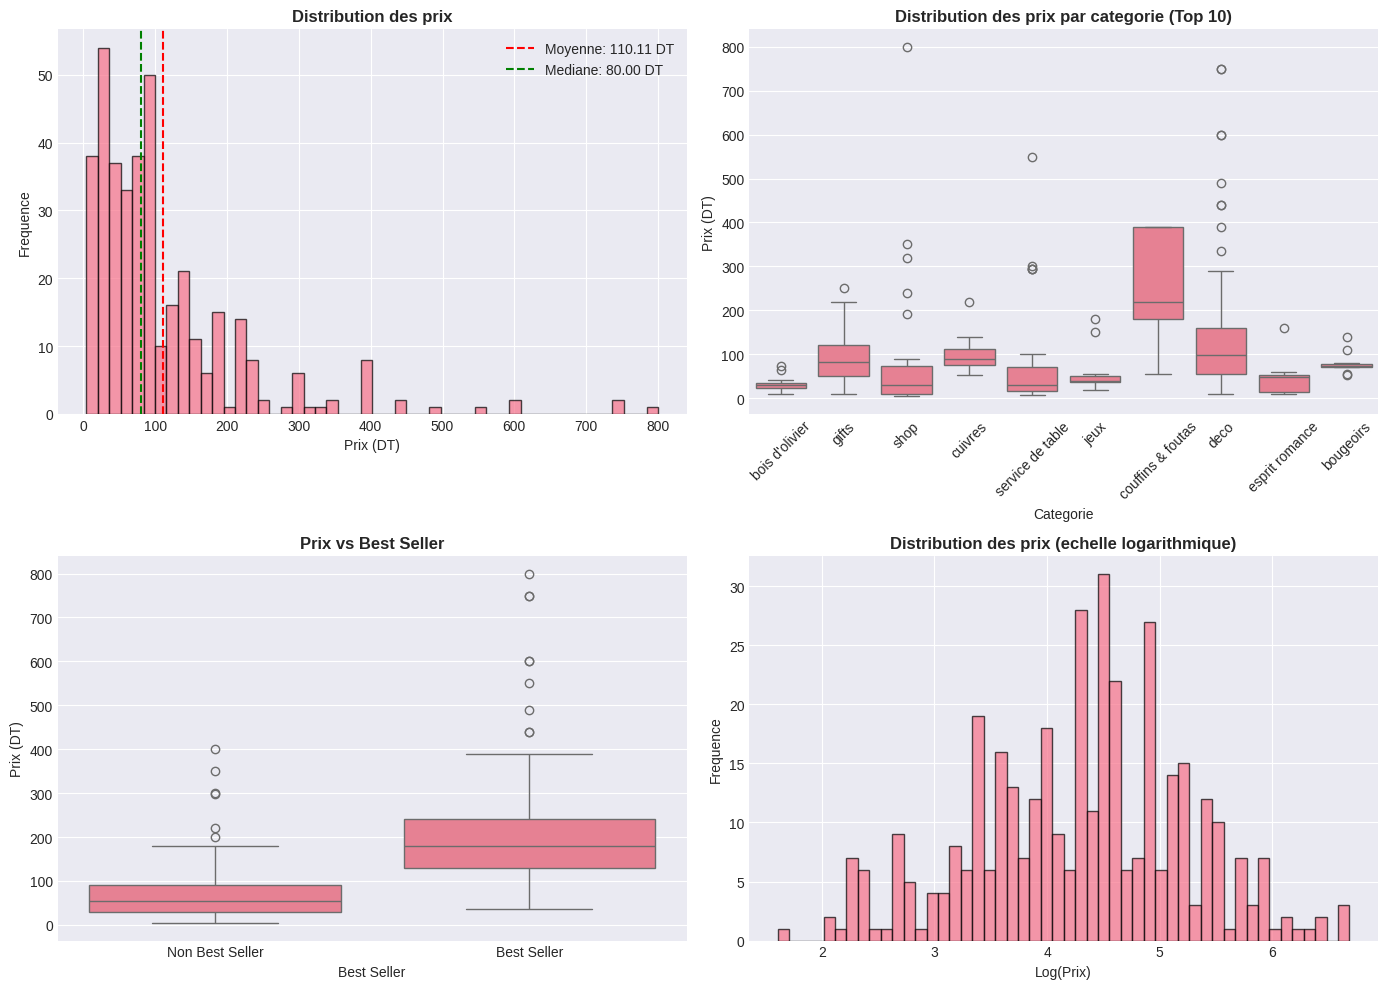


Features utilisees : ['prix', 'log_prix', 'prix_categorie_ratio', 'categorie_encoded', 'company_encoded']
Shape X : (382, 5)


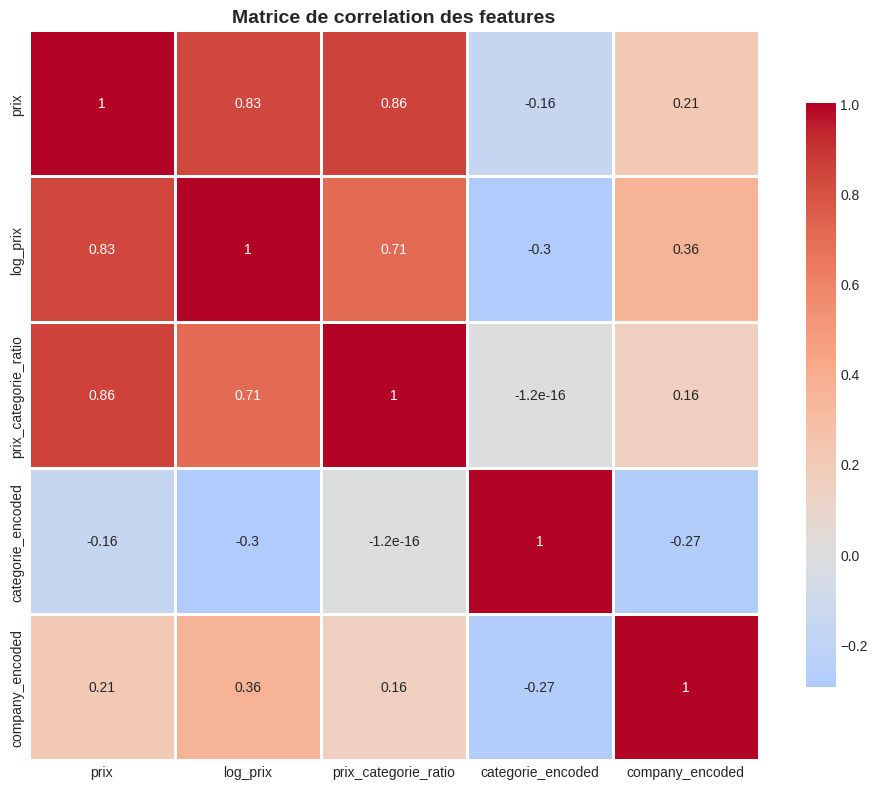


Train : 305 samples
Test : 77 samples

PERFORMANCES XGBOOST
Accuracy  : 0.961
F1-Score  : 0.930
AUC-ROC   : 0.988

Rapport detaille :
                 precision    recall  f1-score   support

Non best seller       0.96      0.98      0.97        55
    Best seller       0.95      0.91      0.93        22

       accuracy                           0.96        77
      macro avg       0.96      0.95      0.95        77
   weighted avg       0.96      0.96      0.96        77



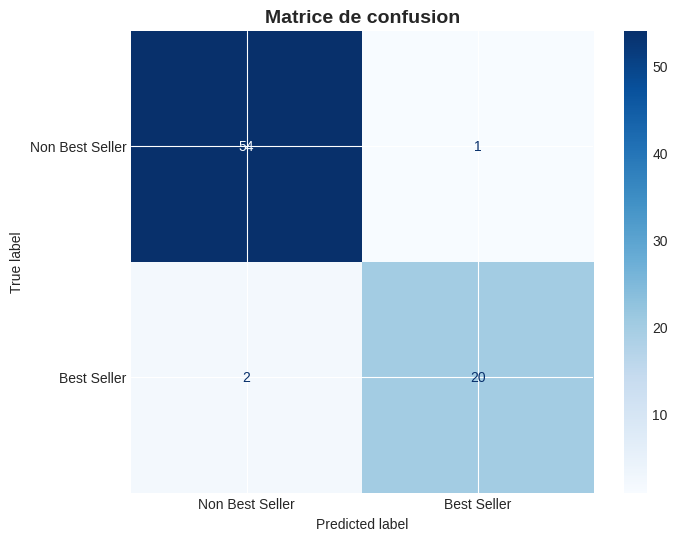

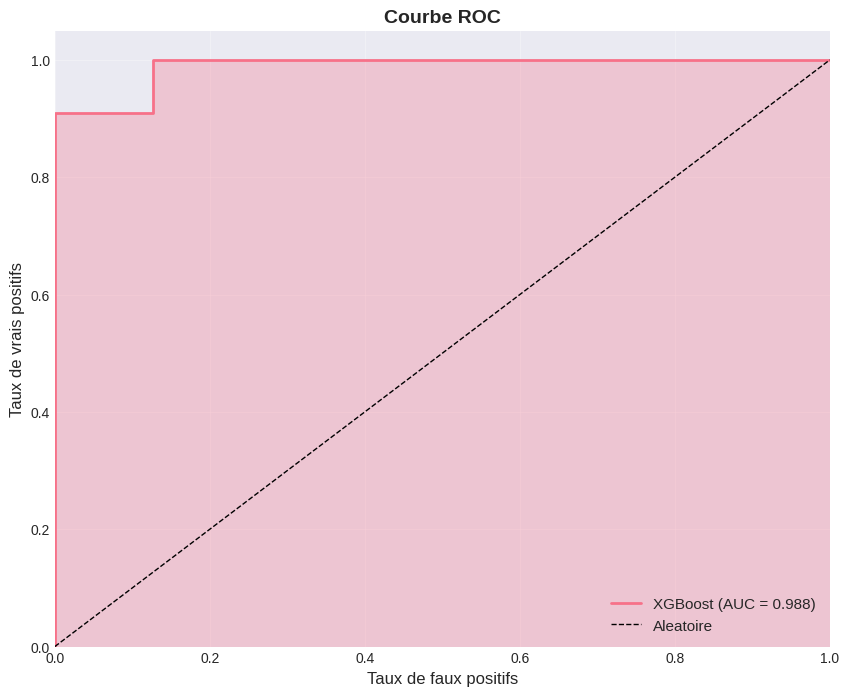


TOP 20 PRODUITS A FORT POTENTIEL
263 | 211.00 DT | 99.7% | deco                 | Pack Vera Craquelé
348 | 190.00 DT | 99.7% | deco                 | Coffret KARA Prestige
349 | 190.00 DT | 99.7% | deco                 | Coffret Lella Prestige
362 | 192.00 DT | 99.7% | deco                 | La ruche
 17 | 180.00 DT | 99.7% | jeux                 | Table Jeux Dchec Avec Tiroirs Pions | 50
214 | 164.00 DT | 99.7% | gifts                | Pack LELLA Craquelé Bleu foncé
216 | 164.00 DT | 99.7% | gifts                | Pack LELLA Craquelé Turquoise
220 | 164.00 DT | 99.7% | gifts                | Pack LELLA Craquelé Miel
222 | 211.00 DT | 99.7% | gifts                | Pack Vera Craquelé
306 | 153.00 DT | 99.7% | gifts                | Le coffret Zouhour Prestige
307 | 190.00 DT | 99.7% | gifts                | Coffret KARA Prestige
190 | 220.00 DT | 99.7% | deco                 | La suspension Doora Gold
191 | 240.00 DT | 99.7% | deco                 | Le cône Nassije
196 | 240.00 DT | 9

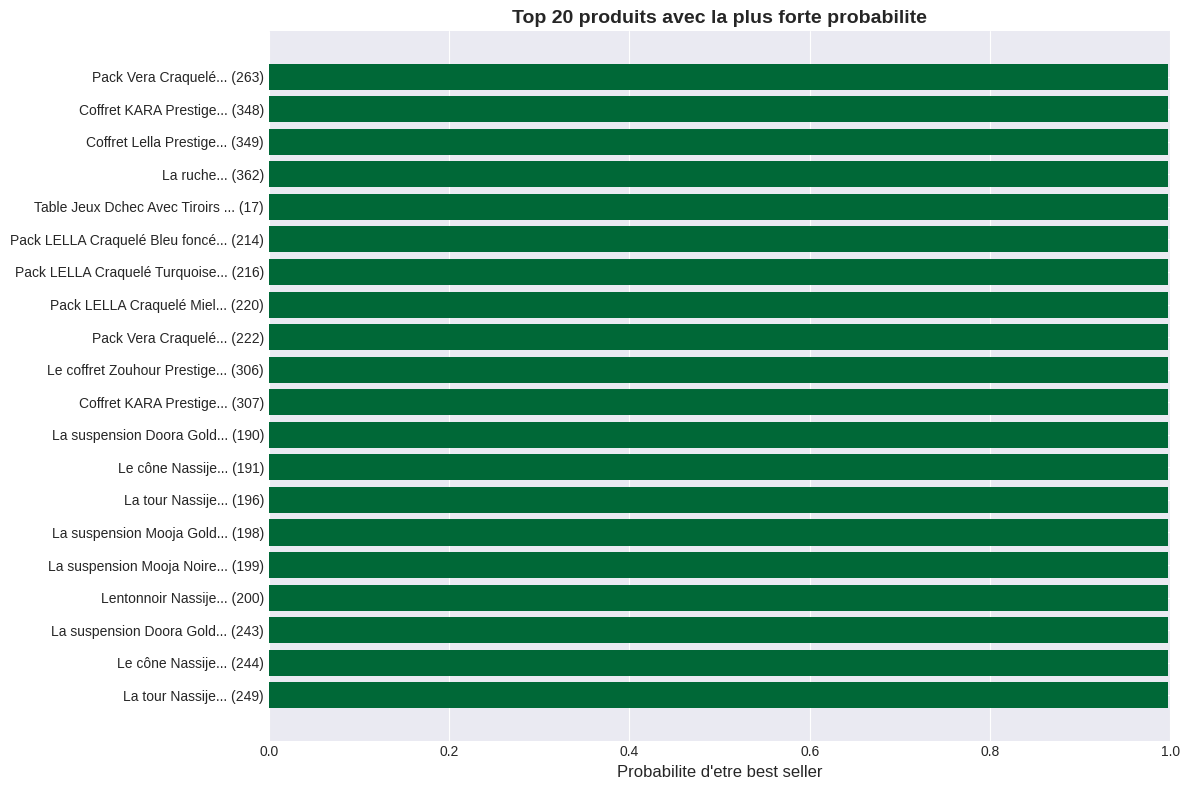


IMPORTANCE DES FEATURES
prix_categorie_ratio      : 0.596
prix                      : 0.162
categorie_encoded         : 0.111
log_prix                  : 0.088
company_encoded           : 0.043


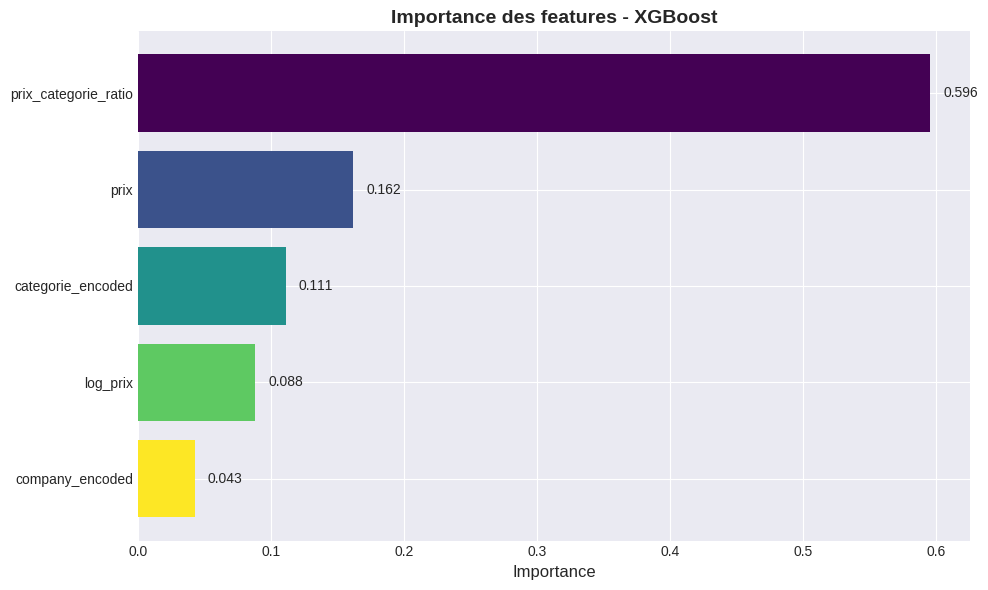

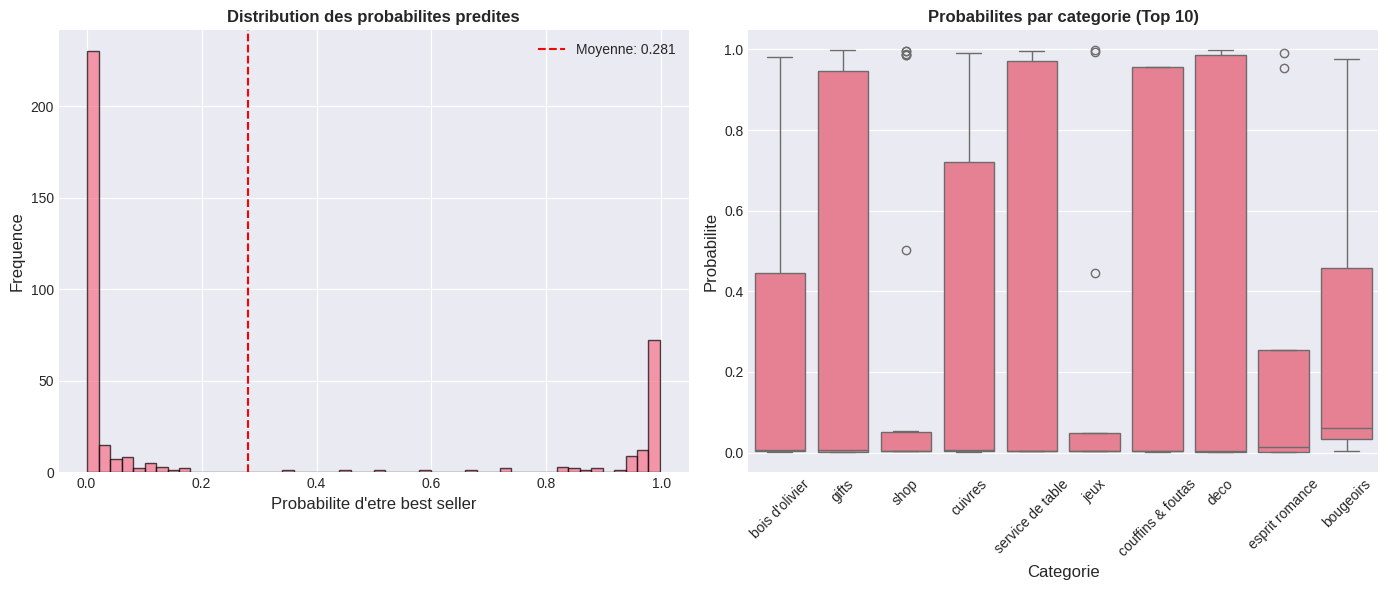

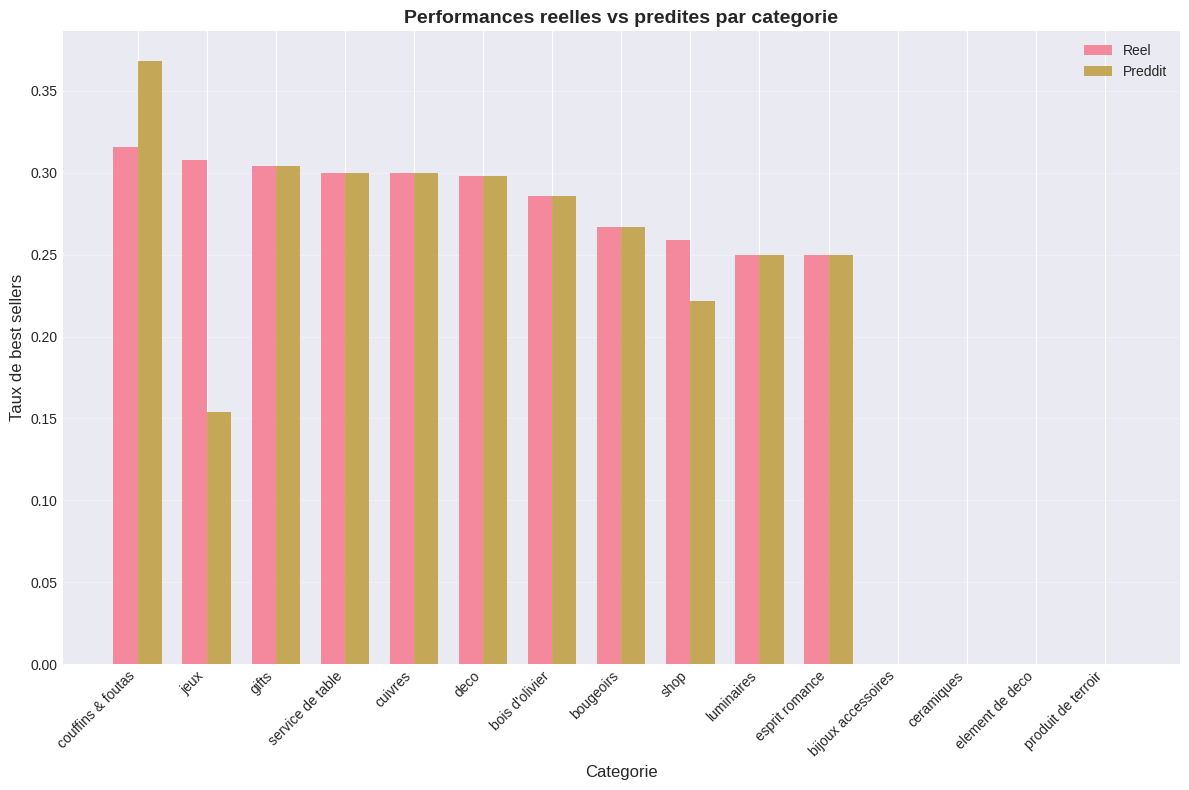


Fichier 'predictions_best_seller.csv' cree

VISUALISATIONS GENEREES
1. distribution_prix.png - Distribution des prix
2. correlation_matrix.png - Matrice de correlation
3. confusion_matrix.png - Matrice de confusion
4. roc_curve.png - Courbe ROC
5. top_products.png - Top produits par probabilite
6. feature_importance.png - Importance des features
7. probability_distribution.png - Distribution des probabilites
8. category_performance.png - Performances par categorie

Toutes les visualisations ont ete sauvegardees


In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, f1_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# ============================================
# 2. CHARGER LE FICHIER
# ============================================

try:
    df = pd.read_excel('all_concurrents.xls', engine='xlrd')
    print("Fichier charge avec engine='xlrd'")
except:
    try:
        df = pd.read_excel('all_concurrents.xls', engine='openpyxl')
        print("Fichier charge avec engine='openpyxl'")
    except:
        print("Conversion necessaire...")
        import subprocess
        subprocess.run(['libreoffice', '--headless', '--convert-to', 'xlsx', 'all_concurrents.xls'])
        df = pd.read_excel('all_concurrents.xlsx', engine='openpyxl')
        print("Fichier converti et charge")

print("\nApercu des donnees :")
print(df.head())
print(f"\nDimension du dataset : {df.shape}")
print(f"\nColonnes disponibles : {df.columns.tolist()}")

# ============================================
# 3. NETTOYAGE DES DONNEES
# ============================================

df.columns = ['id', 'nom', 'prix', 'categorie', 'company']

df['categorie'] = df['categorie'].astype(str).str.lower().str.strip()
df['categorie'] = df['categorie'].replace({
    'boisd\'olivier': 'bois d\'olivier',
    'bois d\'olivier': 'bois d\'olivier',
    'boisd\'olivier': 'bois d\'olivier',
    'bois dolivier': 'bois d\'olivier',
    'céramiques': 'ceramiques',
    'déco': 'deco',
    'service de table': 'service de table'
})

df['prix'] = df['prix'].astype(str).str.replace(',', '.', regex=False)
df['prix'] = df['prix'].str.extract(r'(\d+\.?\d*)')[0]
df['prix'] = pd.to_numeric(df['prix'], errors='coerce')

df = df.dropna(subset=['prix'])
df = df[df['prix'] > 0]
df = df.reset_index(drop=True)

print(f"\nDataset apres nettoyage : {df.shape}")
print(f"\nPrix - Min: {df['prix'].min():.2f} DT, Max: {df['prix'].max():.2f} DT, Moy: {df['prix'].mean():.2f} DT")

# ============================================
# 4. CREER LA CIBLE (BEST SELLER)
# ============================================

df['best_seller'] = df.groupby('categorie')['prix'].transform(
    lambda x: (x > x.quantile(0.7)).astype(int)
)

print(f"\nDistribution de la cible :")
print(df['best_seller'].value_counts())
print(f"Proportion de best sellers : {df['best_seller'].mean():.1%}")

# ============================================
# VISUALISATION 1: Distribution des prix
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df['prix'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Prix (DT)')
axes[0, 0].set_ylabel('Frequence')
axes[0, 0].set_title('Distribution des prix', fontsize=12, fontweight='bold')
axes[0, 0].axvline(df['prix'].mean(), color='red', linestyle='--', label=f'Moyenne: {df["prix"].mean():.2f} DT')
axes[0, 0].axvline(df['prix'].median(), color='green', linestyle='--', label=f'Mediane: {df["prix"].median():.2f} DT')
axes[0, 0].legend()

categories_top = df.groupby('categorie')['prix'].count().nlargest(10).index
df_top_categories = df[df['categorie'].isin(categories_top)]
sns.boxplot(data=df_top_categories, x='categorie', y='prix', ax=axes[0, 1])
axes[0, 1].set_xlabel('Categorie')
axes[0, 1].set_ylabel('Prix (DT)')
axes[0, 1].set_title('Distribution des prix par categorie (Top 10)', fontsize=12, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='best_seller', y='prix', ax=axes[1, 0])
axes[1, 0].set_xlabel('Best Seller')
axes[1, 0].set_ylabel('Prix (DT)')
axes[1, 0].set_title('Prix vs Best Seller', fontsize=12, fontweight='bold')
axes[1, 0].set_xticklabels(['Non Best Seller', 'Best Seller'])

axes[1, 1].hist(np.log1p(df['prix']), bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Log(Prix)')
axes[1, 1].set_ylabel('Frequence')
axes[1, 1].set_title('Distribution des prix (echelle logarithmique)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('distribution_prix.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 5. PREPARER LES FEATURES
# ============================================

le_categorie = LabelEncoder()
le_company = LabelEncoder()

df['categorie_encoded'] = le_categorie.fit_transform(df['categorie'])
df['company_encoded'] = le_company.fit_transform(df['company'])

df['log_prix'] = np.log1p(df['prix'])
df['prix_categorie_ratio'] = df.groupby('categorie')['prix'].transform(
    lambda x: x / x.mean()
)

feature_cols = ['prix', 'log_prix', 'prix_categorie_ratio', 'categorie_encoded', 'company_encoded']
X = df[feature_cols]
y = df['best_seller']

print(f"\nFeatures utilisees : {feature_cols}")
print(f"Shape X : {X.shape}")

# ============================================
# VISUALISATION 2: Matrice de correlation
# ============================================
correlation_matrix = X.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matrice de correlation des features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 6. TRAIN/TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain : {X_train.shape[0]} samples")
print(f"Test : {X_test.shape[0]} samples")

# ============================================
# 7. ENTRAINER XGBOOST
# ============================================

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# ============================================
# 8. EVALUATION
# ============================================

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "="*50)
print("PERFORMANCES XGBOOST")
print("="*50)
print(f"Accuracy  : {accuracy:.3f}")
print(f"F1-Score  : {f1:.3f}")
print(f"AUC-ROC   : {auc:.3f}")
print("\nRapport detaille :")
print(classification_report(y_test, y_pred, target_names=['Non best seller', 'Best seller']))

# ============================================
# VISUALISATION 3: Matrice de confusion
# ============================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non Best Seller', 'Best Seller'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Matrice de confusion', fontsize=14, fontweight='bold')
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# VISUALISATION 4: Courbe ROC
# ============================================
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, linewidth=2, label=f'XGBoost (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatoire')
plt.fill_between(fpr, tpr, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs', fontsize=12)
plt.ylabel('Taux de vrais positifs', fontsize=12)
plt.title('Courbe ROC', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 9. PREDICTION SUR TOUS LES PRODUITS
# ============================================

df['probabilite_best_seller'] = model.predict_proba(X)[:, 1]

print("\n" + "="*50)
print("TOP 20 PRODUITS A FORT POTENTIEL")
print("="*50)

top_20 = df.nlargest(20, 'probabilite_best_seller')[['id', 'nom', 'prix', 'categorie', 'company', 'probabilite_best_seller']]
for idx, row in top_20.iterrows():
    print(f"{int(row['id']):3d} | {row['prix']:6.2f} DT | {row['probabilite_best_seller']:.1%} | {row['categorie']:20s} | {row['nom'][:40]}")

# ============================================
# VISUALISATION 5: Top produits par probabilite
# ============================================
fig, ax = plt.subplots(figsize=(12, 8))
top_products = df.nlargest(20, 'probabilite_best_seller')
colors = plt.cm.RdYlGn(top_products['probabilite_best_seller'] / top_products['probabilite_best_seller'].max())
bars = ax.barh(range(len(top_products)), top_products['probabilite_best_seller'], color=colors)
ax.set_yticks(range(len(top_products)))
ax.set_yticklabels([f"{row['nom'][:30]}... ({int(row['id'])})" for _, row in top_products.iterrows()])
ax.set_xlabel('Probabilite d\'etre best seller', fontsize=12)
ax.set_title('Top 20 produits avec la plus forte probabilite', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig('top_products.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 10. IMPORTANCE DES FEATURES
# ============================================

importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "="*50)
print("IMPORTANCE DES FEATURES")
print("="*50)
for _, row in importance.iterrows():
    print(f"{row['feature']:25s} : {row['importance']:.3f}")

# ============================================
# VISUALISATION 6: Importance des features
# ============================================
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(importance)))
bars = ax.barh(importance['feature'], importance['importance'], color=colors)
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Importance des features - XGBoost', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for i, (_, row) in enumerate(importance.iterrows()):
    ax.text(row['importance'] + 0.01, i, f'{row["importance"]:.3f}',
            va='center', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# VISUALISATION 7: Distribution des probabilites
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].hist(df['probabilite_best_seller'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df['probabilite_best_seller'].mean(), color='red', linestyle='--',
                label=f'Moyenne: {df["probabilite_best_seller"].mean():.3f}')
axes[0].set_xlabel('Probabilite d\'etre best seller', fontsize=12)
axes[0].set_ylabel('Frequence', fontsize=12)
axes[0].set_title('Distribution des probabilites predites', fontsize=12, fontweight='bold')
axes[0].legend()

df_top_categories_prob = df[df['categorie'].isin(categories_top)]
sns.boxplot(data=df_top_categories_prob, x='categorie', y='probabilite_best_seller', ax=axes[1])
axes[1].set_xlabel('Categorie', fontsize=12)
axes[1].set_ylabel('Probabilite', fontsize=12)
axes[1].set_title('Probabilites par categorie (Top 10)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('probability_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# VISUALISATION 8: Performances par categorie
# ============================================
df['predicted'] = model.predict(X)
category_performance = df.groupby('categorie').agg({
    'best_seller': 'mean',
    'predicted': 'mean',
    'probabilite_best_seller': 'mean'
}).round(3).sort_values('best_seller', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
categories = category_performance.index[:15]
x = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x - width/2, category_performance.loc[categories, 'best_seller'],
               width, label='Reel', alpha=0.8)
bars2 = ax.bar(x + width/2, category_performance.loc[categories, 'predicted'],
               width, label='Preddit', alpha=0.8)

ax.set_xlabel('Categorie', fontsize=12)
ax.set_ylabel('Taux de best sellers', fontsize=12)
ax.set_title('Performances reelles vs predites par categorie', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('category_performance.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 11. EXPORTER LES RESULTATS
# ============================================

output = df[['id', 'nom', 'prix', 'categorie', 'company', 'probabilite_best_seller', 'best_seller']]
output = output.sort_values('probabilite_best_seller', ascending=False)
output.to_csv('predictions_best_seller.csv', index=False, encoding='utf-8')

print("\nFichier 'predictions_best_seller.csv' cree")

print("\n" + "="*50)
print("VISUALISATIONS GENEREES")
print("="*50)
print("1. distribution_prix.png - Distribution des prix")
print("2. correlation_matrix.png - Matrice de correlation")
print("3. confusion_matrix.png - Matrice de confusion")
print("4. roc_curve.png - Courbe ROC")
print("5. top_products.png - Top produits par probabilite")
print("6. feature_importance.png - Importance des features")
print("7. probability_distribution.png - Distribution des probabilites")
print("8. category_performance.png - Performances par categorie")
print("\nToutes les visualisations ont ete sauvegardees")

random forest

Fichier charge avec engine='xlrd'

Dataset final : (382, 5)
Prix en DT - Min: 4.00 DT, Max: 800.00 DT, Moy: 110.11 DT

Distribution best seller :
best_seller
0    274
1    108
Name: count, dtype: int64
Proportion : 28.3%


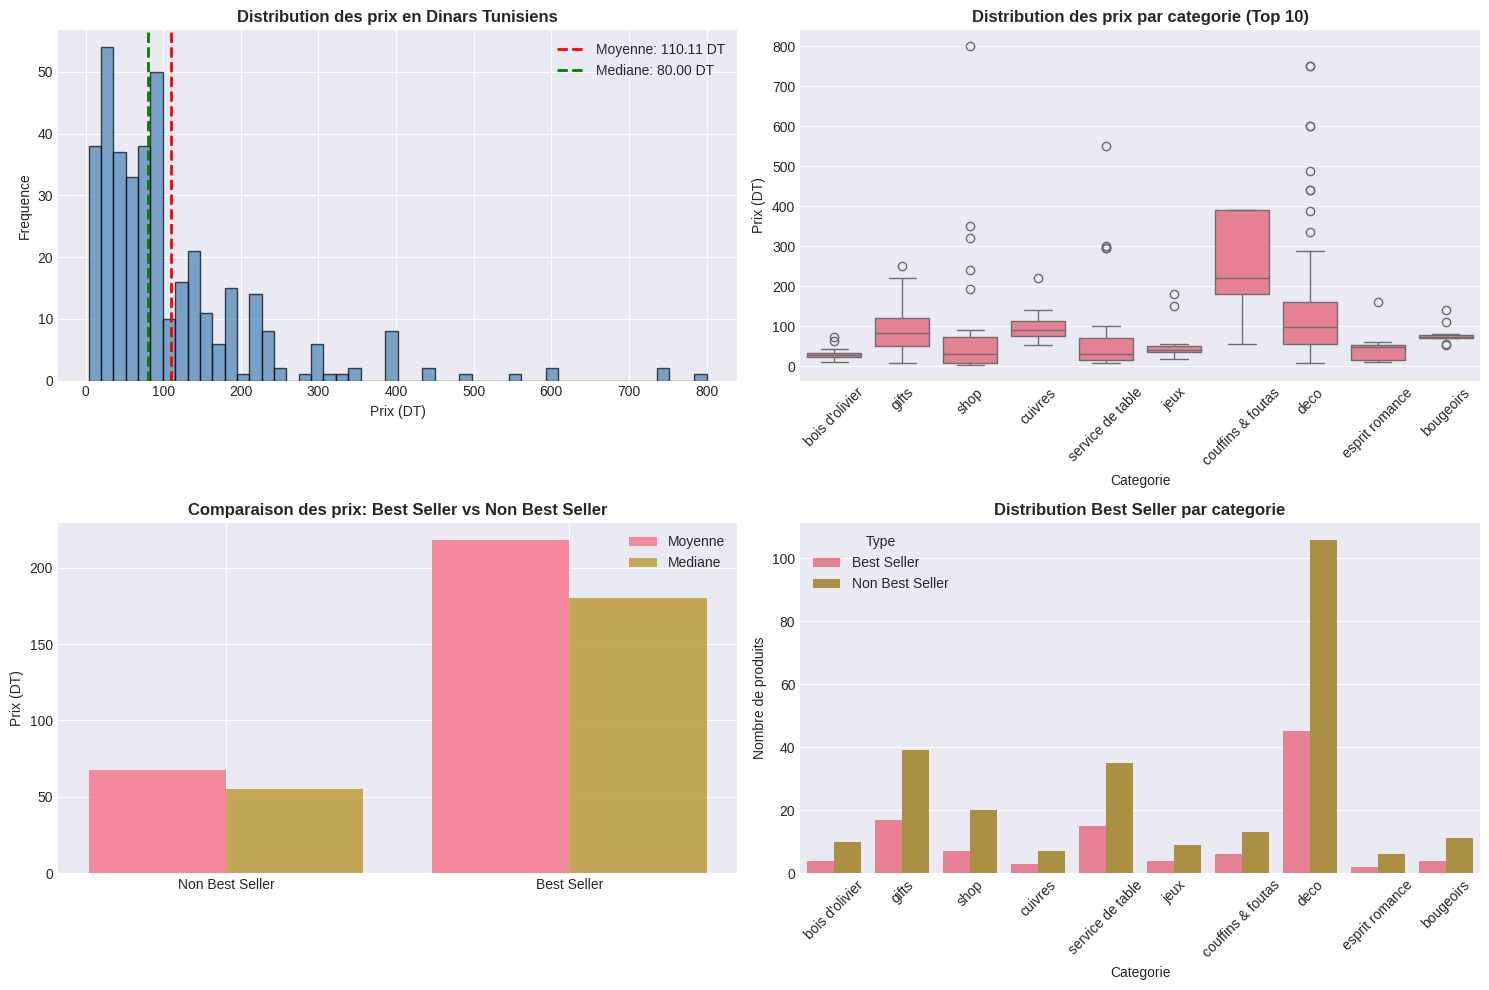


Features : ['prix', 'log_prix', 'prix_normalized', 'prix_categorie_ratio', 'categorie_encoded', 'company_encoded', 'freq_categorie', 'freq_company']


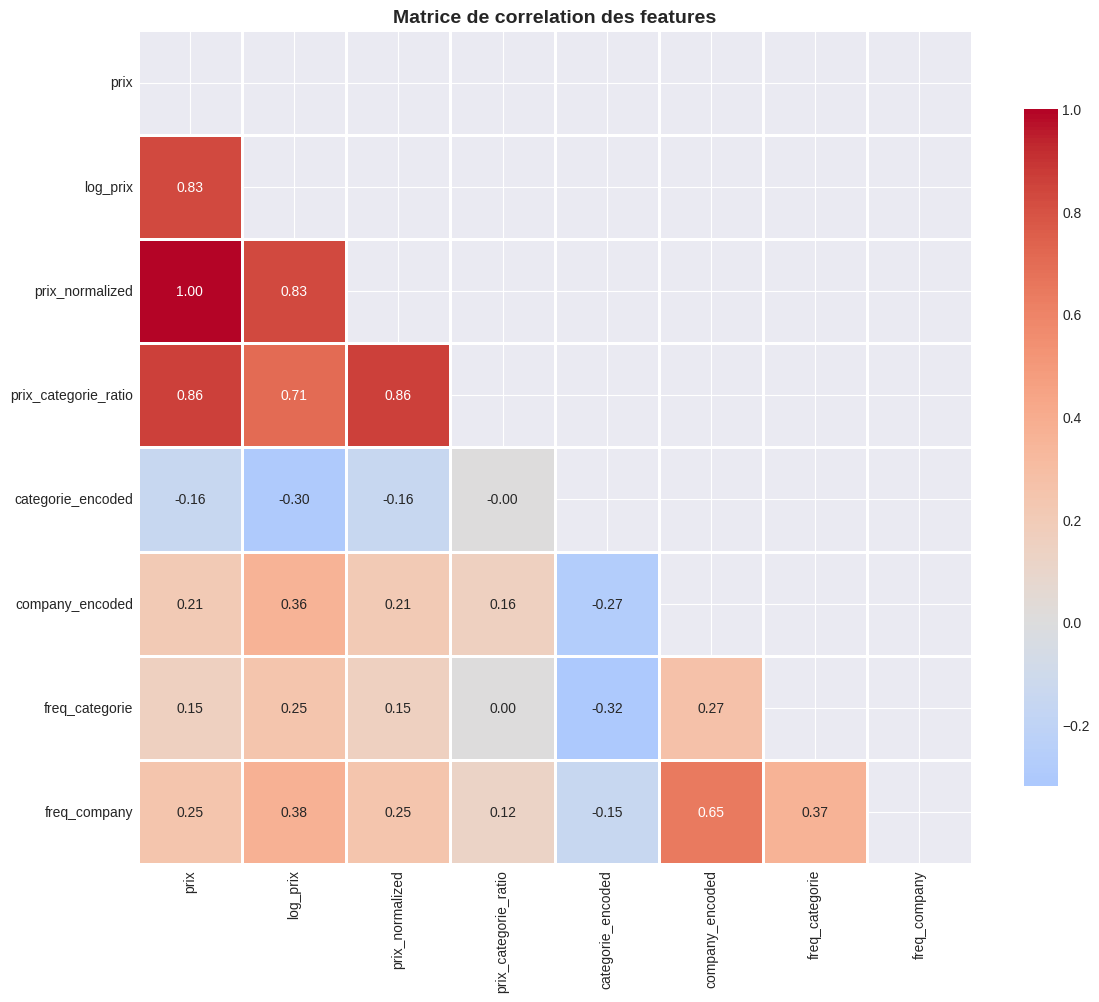


Train : 305 samples
Test : 77 samples

ENTRAINEMENT RANDOM FOREST

PERFORMANCES RANDOM FOREST :
Accuracy  : 0.974
F1-Score  : 0.952
AUC-ROC   : 0.991
Cross-validation (5 folds) : 0.945 (+/- 0.060)

Rapport detaille :
                 precision    recall  f1-score   support

Non best seller       0.96      1.00      0.98        55
    Best seller       1.00      0.91      0.95        22

       accuracy                           0.97        77
      macro avg       0.98      0.95      0.97        77
   weighted avg       0.97      0.97      0.97        77


ENTRAINEMENT XGBOOST

PERFORMANCES XGBOOST :
Accuracy  : 0.974
F1-Score  : 0.952
AUC-ROC   : 0.991

Rapport detaille :
                 precision    recall  f1-score   support

Non best seller       0.96      1.00      0.98        55
    Best seller       1.00      0.91      0.95        22

       accuracy                           0.97        77
      macro avg       0.98      0.95      0.97        77
   weighted avg       0.97    

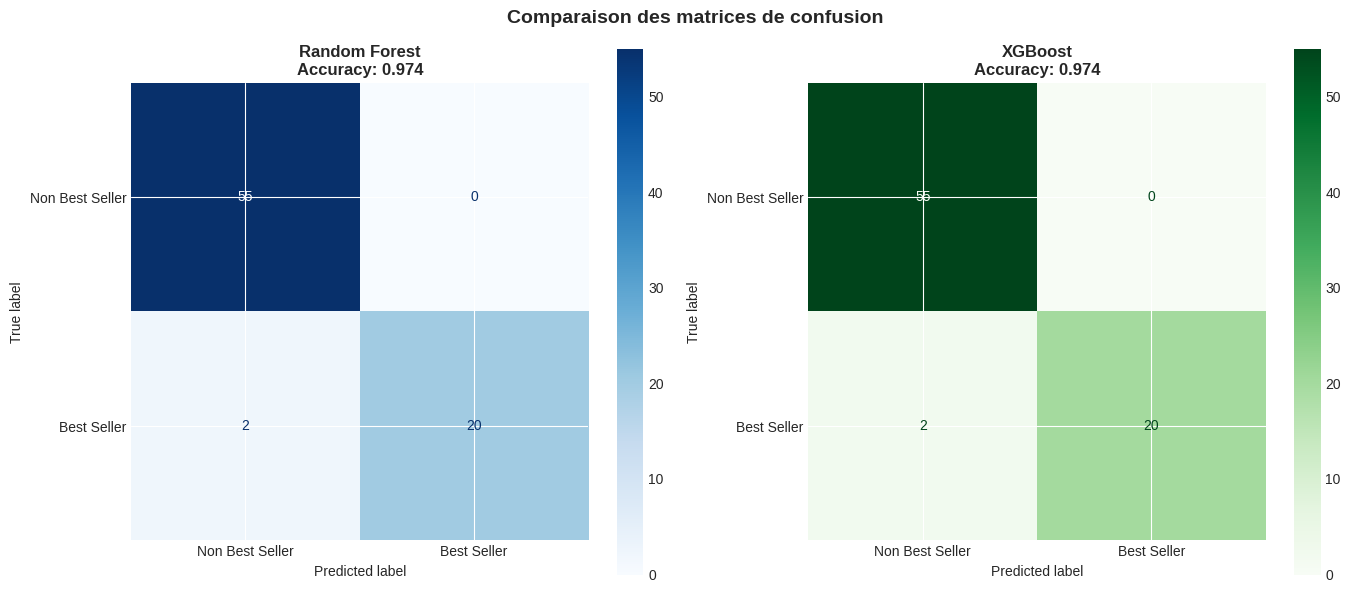

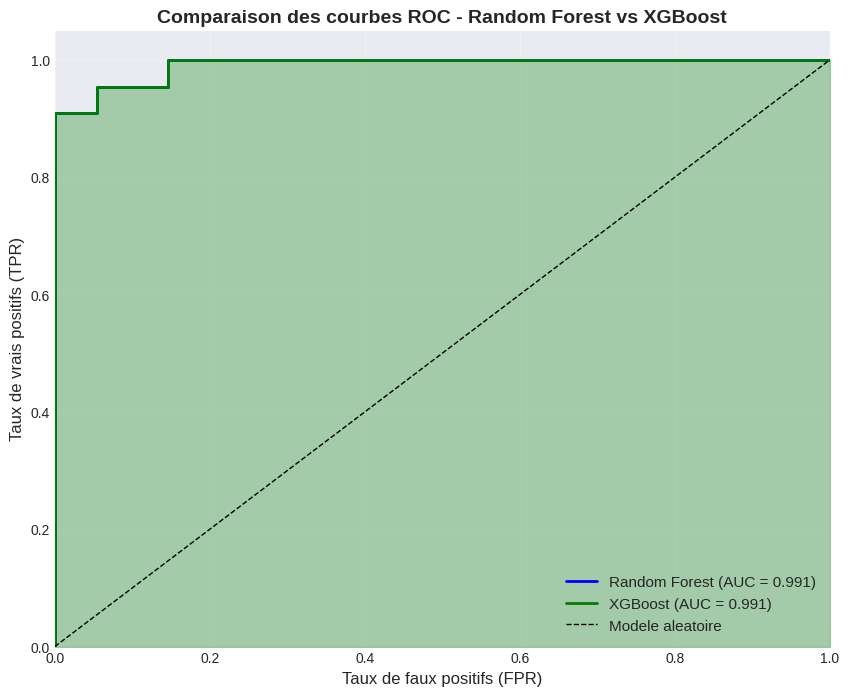


IMPORTANCE DES FEATURES

RANDOM FOREST - Top features :
  prix_categorie_ratio      : 0.379
  prix_normalized           : 0.198
  log_prix                  : 0.165
  prix                      : 0.128
  categorie_encoded         : 0.057

XGBOOST - Top features :
  prix_categorie_ratio      : 0.496
  prix                      : 0.126
  prix_normalized           : 0.097
  freq_categorie            : 0.090
  log_prix                  : 0.090


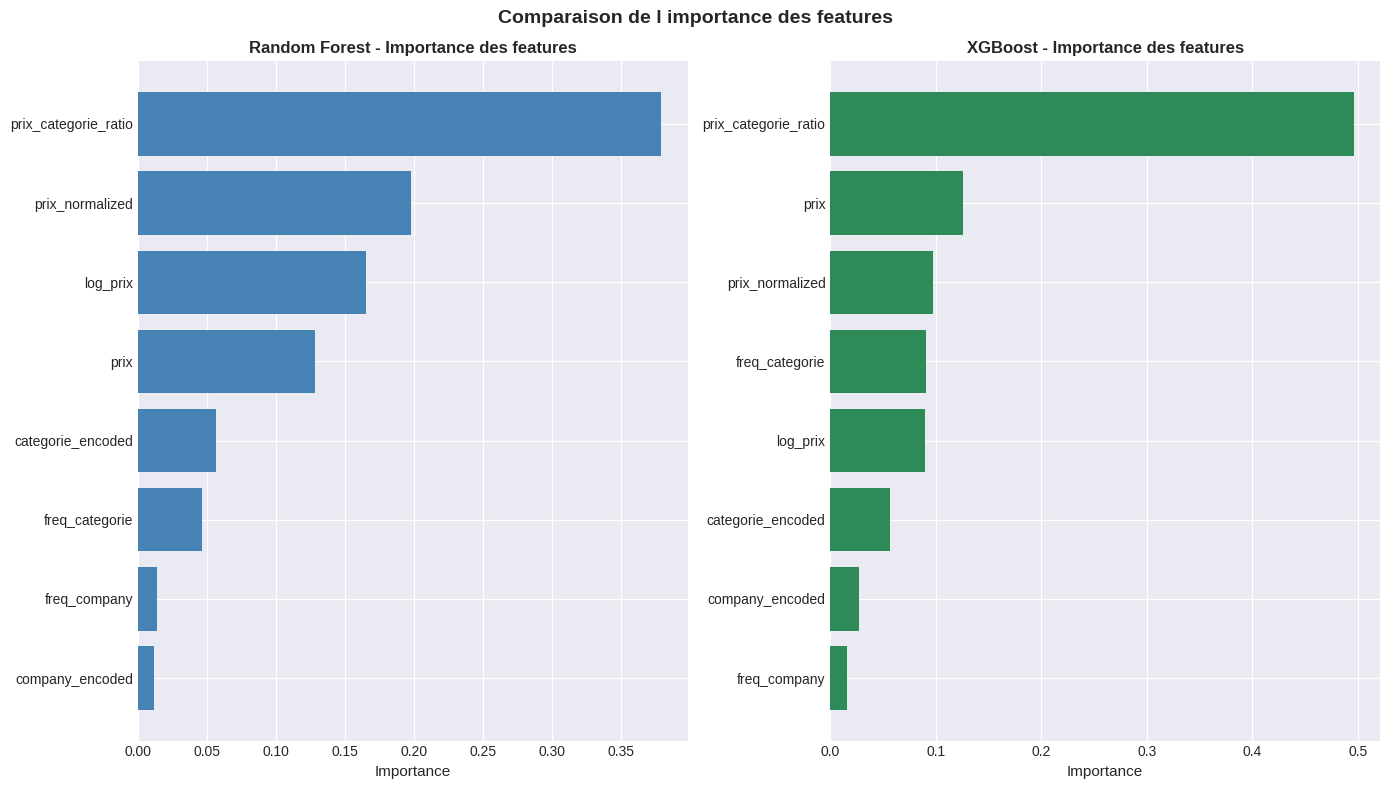

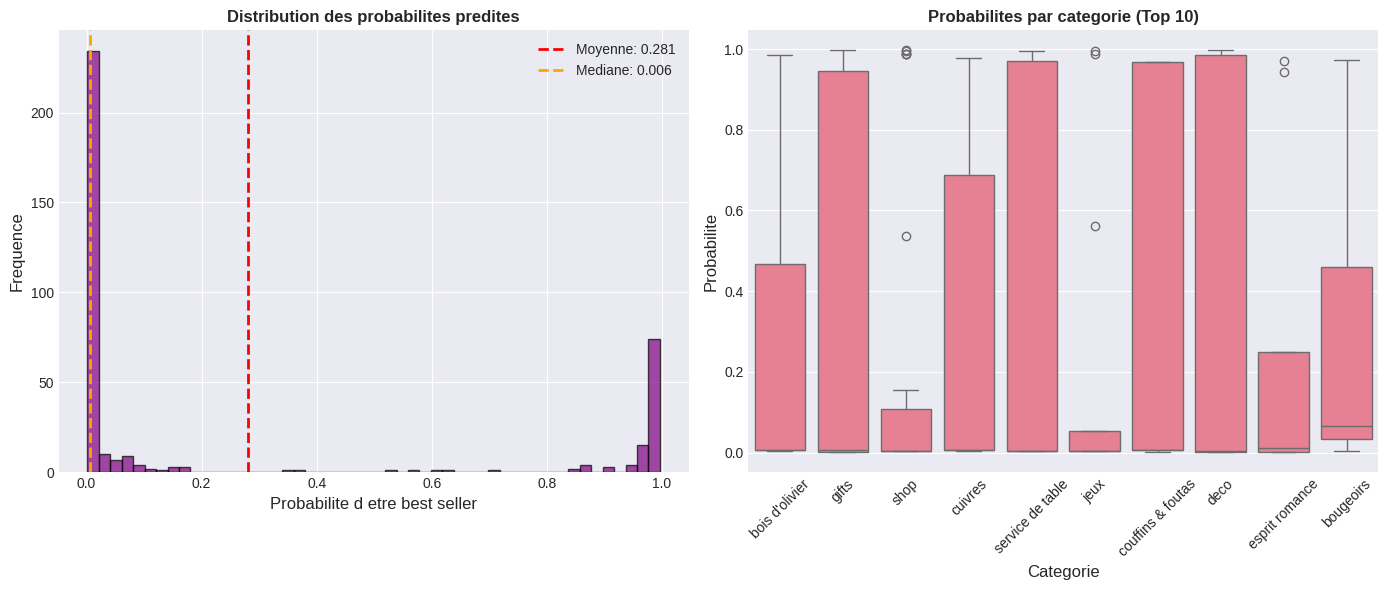


TOP 20 PRODUITS A FORT POTENTIEL (avec XGBoost)
214 | 164.00 DT | 99.7% | gifts                | Pack LELLA Craquelé Bleu foncé
216 | 164.00 DT | 99.7% | gifts                | Pack LELLA Craquelé Turquoise
220 | 164.00 DT | 99.7% | gifts                | Pack LELLA Craquelé Miel
222 | 211.00 DT | 99.7% | gifts                | Pack Vera Craquelé
306 | 153.00 DT | 99.7% | gifts                | Le coffret Zouhour Prestige
307 | 190.00 DT | 99.7% | gifts                | Coffret KARA Prestige
370 | 192.00 DT | 99.7% | shop                 | Lentonnoir
263 | 211.00 DT | 99.6% | deco                 | Pack Vera Craquelé
348 | 190.00 DT | 99.6% | deco                 | Coffret KARA Prestige
349 | 190.00 DT | 99.6% | deco                 | Coffret Lella Prestige
362 | 192.00 DT | 99.6% | deco                 | La ruche
225 | 220.00 DT | 99.6% | gifts                | Pack Lella Marbré Miel
301 | 220.00 DT | 99.6% | gifts                | Coffret ROMA Prestige
372 | 240.00 DT | 99.6% | shop

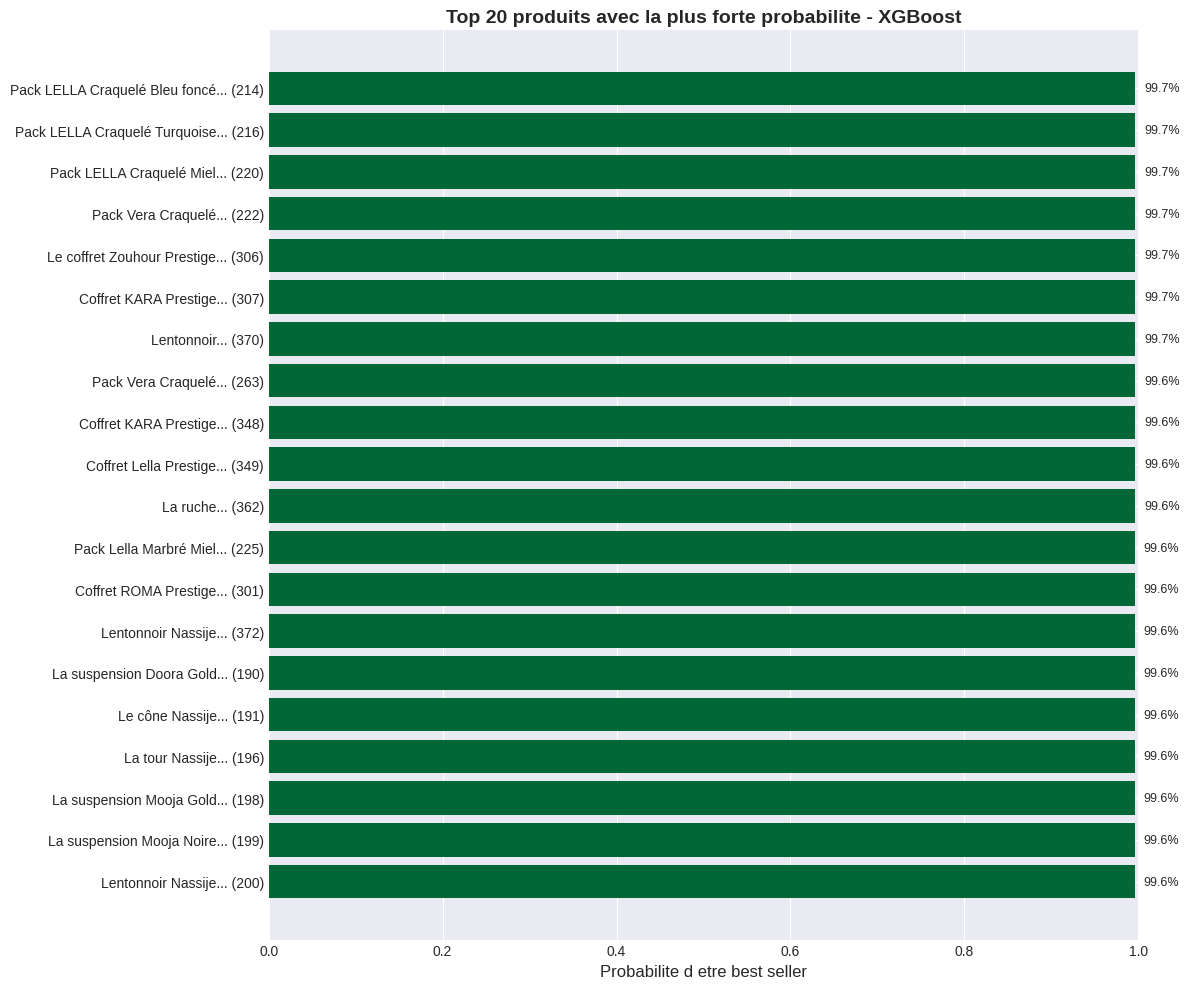


ANALYSE PAR CATEGORIE
                    probabilite_best_seller        prix  nb_produits
categorie                                                           
vases                              0.364544   60.000000            1
couffins & foutas                  0.348919  258.894737           19
service de table                   0.306411   68.520000           50
gifts                              0.303514   94.312321           56
deco                               0.298463  134.000993          151
cuivres                            0.290626  101.890000           10
bougeoirs                          0.276459   78.000000           15
bois d'olivier                     0.257652   32.427857           14
luminaires                         0.253068  132.500000            4
esprit romance                     0.244506   50.625000            8
shop                               0.217057   92.707407           27
jeux                               0.202656   58.000000           13
vase       

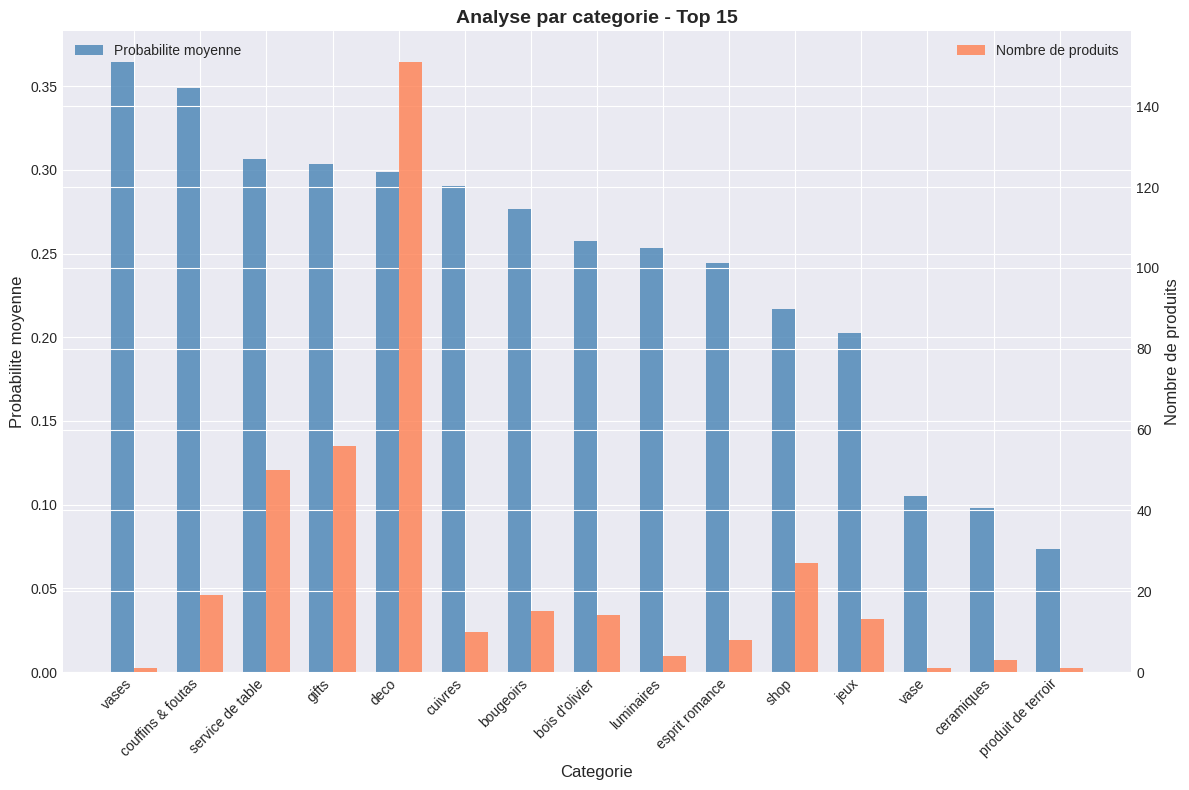


ANALYSE PAR COMPANY
           probabilite_best_seller        prix  nb_produits
company                                                    
kalys                     0.360979  135.003110          209
ileycom                   0.263127   47.465667           30
handmande                 0.167585   86.867133          143


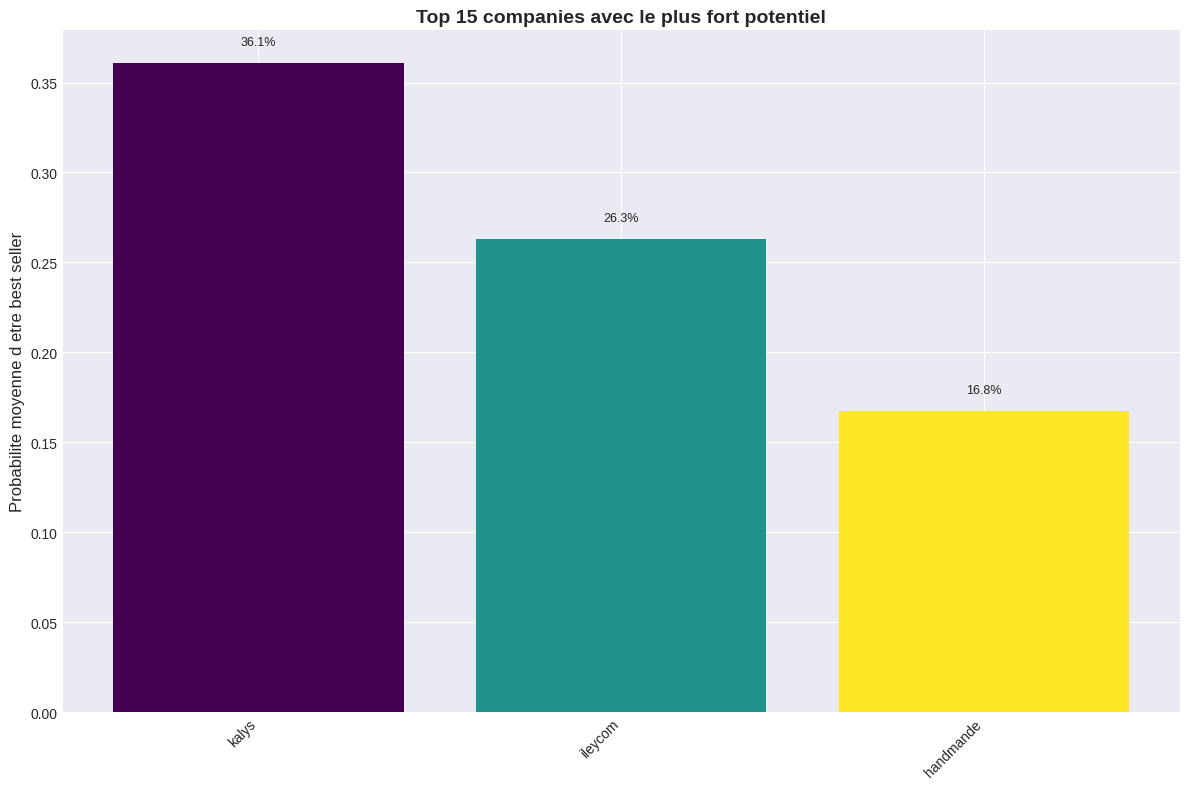

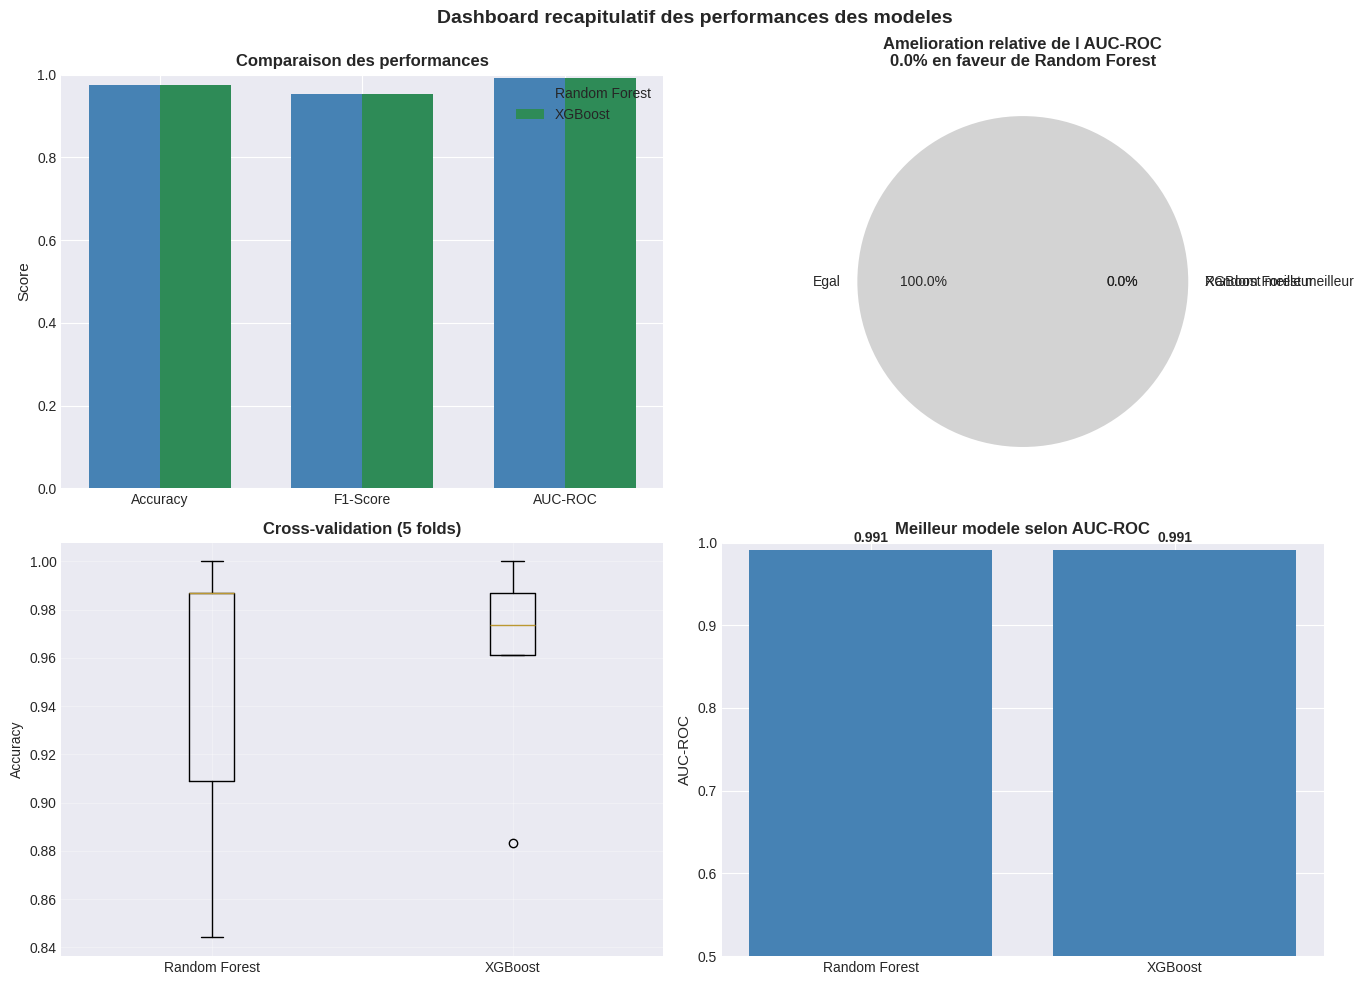


Fichiers crees :
   - predictions_best_seller.csv (classement des produits en DT)
   - comparaison_modeles.csv (performance des modeles)

VISUALISATIONS GENEREES
1. eda_visualizations.png - Analyse exploratoire complete (prix en DT)
2. correlation_matrix.png - Matrice de correlation
3. confusion_matrices_comparison.png - Matrices de confusion comparatives
4. roc_curves_comparison.png - Courbes ROC comparatives
5. feature_importance_comparison.png - Importance des features comparee
6. probability_distribution.png - Distribution des probabilites
7. top_20_products.png - Top 20 produits
8. category_analysis.png - Analyse par categorie
9. company_analysis.png - Analyse par company
10. performance_dashboard.png - Dashboard recapitulatif

Toutes les visualisations ont ete sauvegardees!
Les prix sont en Dinars Tunisiens (DT) - aucune conversion effectuee


In [9]:
!pip install xgboost xlrd openpyxl -q

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Visualisation imports
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, ConfusionMatrixDisplay

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# ============================================
# 2. CHARGER ET NETTOYER LES DONNEES
# ============================================

# Charger le fichier
try:
    df = pd.read_excel('all_concurrents.xls', engine='xlrd')
    print("Fichier charge avec engine='xlrd'")
except:
    df = pd.read_excel('all_concurrents.xls', engine='openpyxl')
    print("Fichier charge avec engine='openpyxl'")

# Renommer les colonnes
df.columns = ['id', 'nom', 'prix', 'categorie', 'company']

# Nettoyer les categories
df['categorie'] = df['categorie'].astype(str).str.lower().str.strip()
df['categorie'] = df['categorie'].replace({
    'boisd\'olivier': 'bois d\'olivier',
    'bois dolivier': 'bois d\'olivier',
    'céramiques': 'ceramiques',
    'déco': 'deco',
    'service de table': 'service de table'
})

# Nettoyer les prix (les valeurs restent les memes, mais sont maintenant en DT)
df['prix'] = df['prix'].astype(str).str.replace(',', '.', regex=False)
df['prix'] = df['prix'].str.extract(r'(\d+\.?\d*)')[0]
df['prix'] = pd.to_numeric(df['prix'], errors='coerce')
df = df.dropna(subset=['prix'])
df = df[df['prix'] > 0]
df = df.reset_index(drop=True)

# Note: Les prix sont en Dinars Tunisiens (DT) - aucune conversion effectuee
print(f"\nDataset final : {df.shape}")
print(f"Prix en DT - Min: {df['prix'].min():.2f} DT, Max: {df['prix'].max():.2f} DT, Moy: {df['prix'].mean():.2f} DT")

# ============================================
# 3. CREER LA CIBLE (BEST SELLER)
# ============================================

# Best seller = prix dans le top 30% de sa categorie
df['best_seller'] = df.groupby('categorie')['prix'].transform(
    lambda x: (x > x.quantile(0.7)).astype(int)
)

print(f"\nDistribution best seller :")
print(df['best_seller'].value_counts())
print(f"Proportion : {df['best_seller'].mean():.1%}")

# ============================================
# VISUALISATION 1: Distribution des prix par categorie
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribution des prix
axes[0, 0].hist(df['prix'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(df['prix'].mean(), color='red', linestyle='--', linewidth=2, label=f'Moyenne: {df["prix"].mean():.2f} DT')
axes[0, 0].axvline(df['prix'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediane: {df["prix"].median():.2f} DT')
axes[0, 0].set_xlabel('Prix (DT)')
axes[0, 0].set_ylabel('Frequence')
axes[0, 0].set_title('Distribution des prix en Dinars Tunisiens', fontsize=12, fontweight='bold')
axes[0, 0].legend()

# Boxplot prix par categorie (top 10)
categories_top = df.groupby('categorie')['prix'].count().nlargest(10).index
df_top_categories = df[df['categorie'].isin(categories_top)]
sns.boxplot(data=df_top_categories, x='categorie', y='prix', ax=axes[0, 1])
axes[0, 1].set_xlabel('Categorie')
axes[0, 1].set_ylabel('Prix (DT)')
axes[0, 1].set_title('Distribution des prix par categorie (Top 10)', fontsize=12, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)

# Distribution best seller vs non best seller
best_seller_stats = df.groupby('best_seller')['prix'].agg(['mean', 'median'])
x_pos = [0, 1]
axes[1, 0].bar(x_pos, best_seller_stats['mean'], width=0.4, label='Moyenne', alpha=0.8)
axes[1, 0].bar([x + 0.4 for x in x_pos], best_seller_stats['median'], width=0.4, label='Mediane', alpha=0.8)
axes[1, 0].set_xticks([x + 0.2 for x in x_pos])
axes[1, 0].set_xticklabels(['Non Best Seller', 'Best Seller'])
axes[1, 0].set_ylabel('Prix (DT)')
axes[1, 0].set_title('Comparaison des prix: Best Seller vs Non Best Seller', fontsize=12, fontweight='bold')
axes[1, 0].legend()

# Countplot des best sellers par categorie
df_top_categories['best_seller_cat'] = df_top_categories['best_seller'].map({0: 'Non Best Seller', 1: 'Best Seller'})
sns.countplot(data=df_top_categories, x='categorie', hue='best_seller_cat', ax=axes[1, 1])
axes[1, 1].set_xlabel('Categorie')
axes[1, 1].set_ylabel('Nombre de produits')
axes[1, 1].set_title('Distribution Best Seller par categorie', fontsize=12, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend(title='Type')

plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 4. FEATURE ENGINEERING
# ============================================

# Encodage
le_categorie = LabelEncoder()
le_company = LabelEncoder()

df['categorie_encoded'] = le_categorie.fit_transform(df['categorie'])
df['company_encoded'] = le_company.fit_transform(df['company'])

# Features numeriques (toujours en DT, pas de conversion)
df['log_prix'] = np.log1p(df['prix'])
df['prix_categorie_ratio'] = df.groupby('categorie')['prix'].transform(lambda x: x / x.mean())
df['prix_normalized'] = (df['prix'] - df['prix'].min()) / (df['prix'].max() - df['prix'].min())

# Features categorielle avancees
df['freq_categorie'] = df.groupby('categorie')['categorie'].transform('count')
df['freq_company'] = df.groupby('company')['company'].transform('count')

# Selection des features
feature_cols = ['prix', 'log_prix', 'prix_normalized', 'prix_categorie_ratio',
                'categorie_encoded', 'company_encoded', 'freq_categorie', 'freq_company']

X = df[feature_cols]
y = df['best_seller']

print(f"\nFeatures : {feature_cols}")

# ============================================
# VISUALISATION 2: Matrice de correlation
# ============================================
plt.figure(figsize=(12, 10))
correlation_matrix = X.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('Matrice de correlation des features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 5. TRAIN/TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain : {X_train.shape[0]} samples")
print(f"Test : {X_test.shape[0]} samples")

# ============================================
# 6. ENTRAINER RANDOM FOREST
# ============================================

print("\n" + "="*60)
print("ENTRAINEMENT RANDOM FOREST")
print("="*60)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions
rf_y_pred = rf_model.predict(X_test)
rf_y_proba = rf_model.predict_proba(X_test)[:, 1]

# Metriques
rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_f1 = f1_score(y_test, rf_y_pred)
rf_auc = roc_auc_score(y_test, rf_y_proba)

print(f"\nPERFORMANCES RANDOM FOREST :")
print(f"Accuracy  : {rf_accuracy:.3f}")
print(f"F1-Score  : {rf_f1:.3f}")
print(f"AUC-ROC   : {rf_auc:.3f}")
print(f"Cross-validation (5 folds) : {cross_val_score(rf_model, X, y, cv=5).mean():.3f} (+/- {cross_val_score(rf_model, X, y, cv=5).std():.3f})")

print("\nRapport detaille :")
print(classification_report(y_test, rf_y_pred, target_names=['Non best seller', 'Best seller']))

# ============================================
# 7. ENTRAINER XGBOOST (comparaison)
# ============================================

print("\n" + "="*60)
print("ENTRAINEMENT XGBOOST")
print("="*60)

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_model.fit(X_train, y_train)

# Predictions
xgb_y_pred = xgb_model.predict(X_test)
xgb_y_proba = xgb_model.predict_proba(X_test)[:, 1]

# Metriques
xgb_accuracy = accuracy_score(y_test, xgb_y_pred)
xgb_f1 = f1_score(y_test, xgb_y_pred)
xgb_auc = roc_auc_score(y_test, xgb_y_proba)

print(f"\nPERFORMANCES XGBOOST :")
print(f"Accuracy  : {xgb_accuracy:.3f}")
print(f"F1-Score  : {xgb_f1:.3f}")
print(f"AUC-ROC   : {xgb_auc:.3f}")

print("\nRapport detaille :")
print(classification_report(y_test, xgb_y_pred, target_names=['Non best seller', 'Best seller']))

# ============================================
# 8. COMPARAISON DES MODELES
# ============================================

print("\n" + "="*60)
print("COMPARAISON DES MODELES")
print("="*60)

comparaison = pd.DataFrame({
    'Modele': ['Random Forest', 'XGBoost'],
    'Accuracy': [rf_accuracy, xgb_accuracy],
    'F1-Score': [rf_f1, xgb_f1],
    'AUC-ROC': [rf_auc, xgb_auc]
})

print(comparaison.to_string(index=False))

# Determiner le meilleur modele
best_model = 'Random Forest' if rf_auc > xgb_auc else 'XGBoost'
print(f"\nMEILLEUR MODELE : {best_model} (base sur AUC-ROC)")

# ============================================
# VISUALISATION 3: Matrices de confusion comparatives
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Matrice de confusion Random Forest
cm_rf = confusion_matrix(y_test, rf_y_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Non Best Seller', 'Best Seller'])
disp_rf.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'Random Forest\nAccuracy: {rf_accuracy:.3f}', fontsize=12, fontweight='bold')

# Matrice de confusion XGBoost
cm_xgb = confusion_matrix(y_test, xgb_y_pred)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Non Best Seller', 'Best Seller'])
disp_xgb.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title(f'XGBoost\nAccuracy: {xgb_accuracy:.3f}', fontsize=12, fontweight='bold')

plt.suptitle('Comparaison des matrices de confusion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# VISUALISATION 4: Courbes ROC comparatives
# ============================================
plt.figure(figsize=(10, 8))

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_y_proba)
plt.plot(fpr_rf, tpr_rf, linewidth=2, label=f'Random Forest (AUC = {rf_auc:.3f})', color='blue')

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_y_proba)
plt.plot(fpr_xgb, tpr_xgb, linewidth=2, label=f'XGBoost (AUC = {xgb_auc:.3f})', color='green')

# Baseline
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Modele aleatoire')

# Remplir l'aire sous la courbe du meilleur modele
if rf_auc > xgb_auc:
    plt.fill_between(fpr_rf, tpr_rf, alpha=0.3, color='blue')
else:
    plt.fill_between(fpr_xgb, tpr_xgb, alpha=0.3, color='green')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs (FPR)', fontsize=12)
plt.ylabel('Taux de vrais positifs (TPR)', fontsize=12)
plt.title('Comparaison des courbes ROC - Random Forest vs XGBoost', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig('roc_curves_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 9. IMPORTANCE DES FEATURES
# ============================================

print("\n" + "="*60)
print("IMPORTANCE DES FEATURES")
print("="*60)

# Random Forest
rf_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance_rf': rf_model.feature_importances_
}).sort_values('importance_rf', ascending=False)

# XGBoost
xgb_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance_xgb': xgb_model.feature_importances_
}).sort_values('importance_xgb', ascending=False)

print("\nRANDOM FOREST - Top features :")
for _, row in rf_importance.head(5).iterrows():
    print(f"  {row['feature']:25s} : {row['importance_rf']:.3f}")

print("\nXGBOOST - Top features :")
for _, row in xgb_importance.head(5).iterrows():
    print(f"  {row['feature']:25s} : {row['importance_xgb']:.3f}")

# ============================================
# VISUALISATION 5: Importance des features comparee
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Random Forest
rf_importance_sorted = rf_importance.sort_values('importance_rf', ascending=True)
axes[0].barh(rf_importance_sorted['feature'], rf_importance_sorted['importance_rf'], color='steelblue')
axes[0].set_xlabel('Importance', fontsize=11)
axes[0].set_title('Random Forest - Importance des features', fontsize=12, fontweight='bold')

# XGBoost
xgb_importance_sorted = xgb_importance.sort_values('importance_xgb', ascending=True)
axes[1].barh(xgb_importance_sorted['feature'], xgb_importance_sorted['importance_xgb'], color='seagreen')
axes[1].set_xlabel('Importance', fontsize=11)
axes[1].set_title('XGBoost - Importance des features', fontsize=12, fontweight='bold')

plt.suptitle('Comparaison de l importance des features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# VISUALISATION 6: Distribution des probabilites
# ============================================
# Predictions avec le meilleur modele
best_classifier = rf_model if rf_auc > xgb_auc else xgb_model
df['probabilite_best_seller'] = best_classifier.predict_proba(X)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Distribution des probabilites
axes[0].hist(df['probabilite_best_seller'], bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[0].axvline(df['probabilite_best_seller'].mean(), color='red', linestyle='--',
                linewidth=2, label=f'Moyenne: {df["probabilite_best_seller"].mean():.3f}')
axes[0].axvline(df['probabilite_best_seller'].median(), color='orange', linestyle='--',
                linewidth=2, label=f'Mediane: {df["probabilite_best_seller"].median():.3f}')
axes[0].set_xlabel('Probabilite d etre best seller', fontsize=12)
axes[0].set_ylabel('Frequence', fontsize=12)
axes[0].set_title('Distribution des probabilites predites', fontsize=12, fontweight='bold')
axes[0].legend()

# Boxplot des probabilites par categorie
df_top_categories = df[df['categorie'].isin(categories_top)]
sns.boxplot(data=df_top_categories, x='categorie', y='probabilite_best_seller', ax=axes[1])
axes[1].set_xlabel('Categorie', fontsize=12)
axes[1].set_ylabel('Probabilite', fontsize=12)
axes[1].set_title('Probabilites par categorie (Top 10)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('probability_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 10. PREDICTION SUR TOUS LES PRODUITS (MEILLEUR MODELE)
# ============================================

print("\n" + "="*60)
print(f"TOP 20 PRODUITS A FORT POTENTIEL (avec {best_model})")
print("="*60)

top_20 = df.nlargest(20, 'probabilite_best_seller')[['id', 'nom', 'prix', 'categorie', 'company', 'probabilite_best_seller']]
for idx, row in top_20.iterrows():
    print(f"{int(row['id']):3d} | {row['prix']:6.2f} DT | {row['probabilite_best_seller']:.1%} | {row['categorie']:20s} | {row['nom'][:40]}")

# ============================================
# VISUALISATION 7: Top 20 produits
# ============================================
fig, ax = plt.subplots(figsize=(12, 10))
top_products = df.nlargest(20, 'probabilite_best_seller')
colors = plt.cm.RdYlGn(top_products['probabilite_best_seller'] / top_products['probabilite_best_seller'].max())
bars = ax.barh(range(len(top_products)), top_products['probabilite_best_seller'], color=colors)
ax.set_yticks(range(len(top_products)))
ax.set_yticklabels([f"{row['nom'][:35]}... ({int(row['id'])})" for _, row in top_products.iterrows()])
ax.set_xlabel('Probabilite d etre best seller', fontsize=12)
ax.set_title(f'Top 20 produits avec la plus forte probabilite - {best_model}', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.set_xlim(0, 1)

# Ajouter les valeurs sur les barres
for i, (_, row) in enumerate(top_products.iterrows()):
    ax.text(row['probabilite_best_seller'] + 0.01, i, f'{row["probabilite_best_seller"]:.1%}',
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top_20_products.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 11. ANALYSE PAR CATEGORIE
# ============================================

print("\n" + "="*60)
print("ANALYSE PAR CATEGORIE")
print("="*60)

categorie_analysis = df.groupby('categorie').agg({
    'probabilite_best_seller': 'mean',
    'prix': 'mean',
    'id': 'count'
}).rename(columns={'id': 'nb_produits'}).sort_values('probabilite_best_seller', ascending=False)

print(categorie_analysis.to_string())

# ============================================
# VISUALISATION 8: Performances par categorie
# ============================================
fig, ax = plt.subplots(figsize=(12, 8))
top_categories = categorie_analysis.head(15)
x = np.arange(len(top_categories))
width = 0.35

bars1 = ax.bar(x - width/2, top_categories['probabilite_best_seller'], width,
               label='Probabilite moyenne', alpha=0.8, color='steelblue')
ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, top_categories['nb_produits'], width,
                label='Nombre de produits', alpha=0.8, color='coral')

ax.set_xlabel('Categorie', fontsize=12)
ax.set_ylabel('Probabilite moyenne', fontsize=12)
ax2.set_ylabel('Nombre de produits', fontsize=12)
ax.set_title('Analyse par categorie - Top 15', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(top_categories.index, rotation=45, ha='right')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('category_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 12. ANALYSE PAR COMPANY
# ============================================

print("\n" + "="*60)
print("ANALYSE PAR COMPANY")
print("="*60)

company_analysis = df.groupby('company').agg({
    'probabilite_best_seller': 'mean',
    'prix': 'mean',
    'id': 'count'
}).rename(columns={'id': 'nb_produits'}).sort_values('probabilite_best_seller', ascending=False)

print(company_analysis.to_string())

# ============================================
# VISUALISATION 9: Top companies
# ============================================
fig, ax = plt.subplots(figsize=(12, 8))
top_companies = company_analysis.head(15)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_companies)))
bars = ax.bar(range(len(top_companies)), top_companies['probabilite_best_seller'], color=colors)
ax.set_xticks(range(len(top_companies)))
ax.set_xticklabels(top_companies.index, rotation=45, ha='right')
ax.set_ylabel('Probabilite moyenne d etre best seller', fontsize=12)
ax.set_title('Top 15 companies avec le plus fort potentiel', fontsize=14, fontweight='bold')

# Ajouter les valeurs sur les barres
for i, (_, row) in enumerate(top_companies.iterrows()):
    ax.text(i, row['probabilite_best_seller'] + 0.01, f'{row["probabilite_best_seller"]:.1%}',
            ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('company_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# VISUALISATION 10: Dashboard recapitulatif des performances
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Barplot des metriques
metrics = ['Accuracy', 'F1-Score', 'AUC-ROC']
rf_scores = [rf_accuracy, rf_f1, rf_auc]
xgb_scores = [xgb_accuracy, xgb_f1, xgb_auc]

x = np.arange(len(metrics))
width = 0.35
axes[0, 0].bar(x - width/2, rf_scores, width, label='Random Forest', color='steelblue')
axes[0, 0].bar(x + width/2, xgb_scores, width, label='XGBoost', color='seagreen')
axes[0, 0].set_ylabel('Score', fontsize=11)
axes[0, 0].set_title('Comparaison des performances', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metrics)
axes[0, 0].legend()
axes[0, 0].set_ylim([0, 1])

# Amelioration relative
improvement = ((xgb_auc - rf_auc) / rf_auc) * 100
axes[0, 1].pie([max(0, improvement), max(0, -improvement), 100 - abs(improvement)],
               labels=['XGBoost meilleur', 'Random Forest meilleur', 'Egal'],
               autopct='%1.1f%%', colors=['seagreen', 'steelblue', 'lightgray'])
axes[0, 1].set_title(f'Amelioration relative de l AUC-ROC\n{abs(improvement):.1f}% en faveur de {"XGBoost" if improvement > 0 else "Random Forest"}',
                     fontsize=12, fontweight='bold')

# Cross-validation scores
rf_cv_scores = cross_val_score(rf_model, X, y, cv=5)
xgb_cv_scores = cross_val_score(xgb_model, X, y, cv=5)
axes[1, 0].boxplot([rf_cv_scores, xgb_cv_scores], labels=['Random Forest', 'XGBoost'])
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Cross-validation (5 folds)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Evolution des performances
models = ['Random Forest', 'XGBoost']
scores = [rf_auc, xgb_auc]
colors_bar = ['steelblue' if s == max(scores) else 'lightgray' for s in scores]
axes[1, 1].bar(models, scores, color=colors_bar)
axes[1, 1].set_ylabel('AUC-ROC', fontsize=11)
axes[1, 1].set_title('Meilleur modele selon AUC-ROC', fontsize=12, fontweight='bold')
axes[1, 1].set_ylim([0.5, 1])
for i, (model, score) in enumerate(zip(models, scores)):
    axes[1, 1].text(i, score + 0.01, f'{score:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Dashboard recapitulatif des performances des modeles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('performance_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 13. EXPORTER LES RESULTATS
# ============================================

# Export complet
output = df[['id', 'nom', 'prix', 'categorie', 'company', 'probabilite_best_seller', 'best_seller']]
output = output.sort_values('probabilite_best_seller', ascending=False)
output.to_csv('predictions_best_seller.csv', index=False, encoding='utf-8')

# Export comparaison modeles
comparaison.to_csv('comparaison_modeles.csv', index=False)

print("\nFichiers crees :")
print("   - predictions_best_seller.csv (classement des produits en DT)")
print("   - comparaison_modeles.csv (performance des modeles)")

print("\n" + "="*60)
print("VISUALISATIONS GENEREES")
print("="*60)
print("1. eda_visualizations.png - Analyse exploratoire complete (prix en DT)")
print("2. correlation_matrix.png - Matrice de correlation")
print("3. confusion_matrices_comparison.png - Matrices de confusion comparatives")
print("4. roc_curves_comparison.png - Courbes ROC comparatives")
print("5. feature_importance_comparison.png - Importance des features comparee")
print("6. probability_distribution.png - Distribution des probabilites")
print("7. top_20_products.png - Top 20 produits")
print("8. category_analysis.png - Analyse par categorie")
print("9. company_analysis.png - Analyse par company")
print("10. performance_dashboard.png - Dashboard recapitulatif")
print("\nToutes les visualisations ont ete sauvegardees!")
print("Les prix sont en Dinars Tunisiens (DT) - aucune conversion effectuee")

Comparison

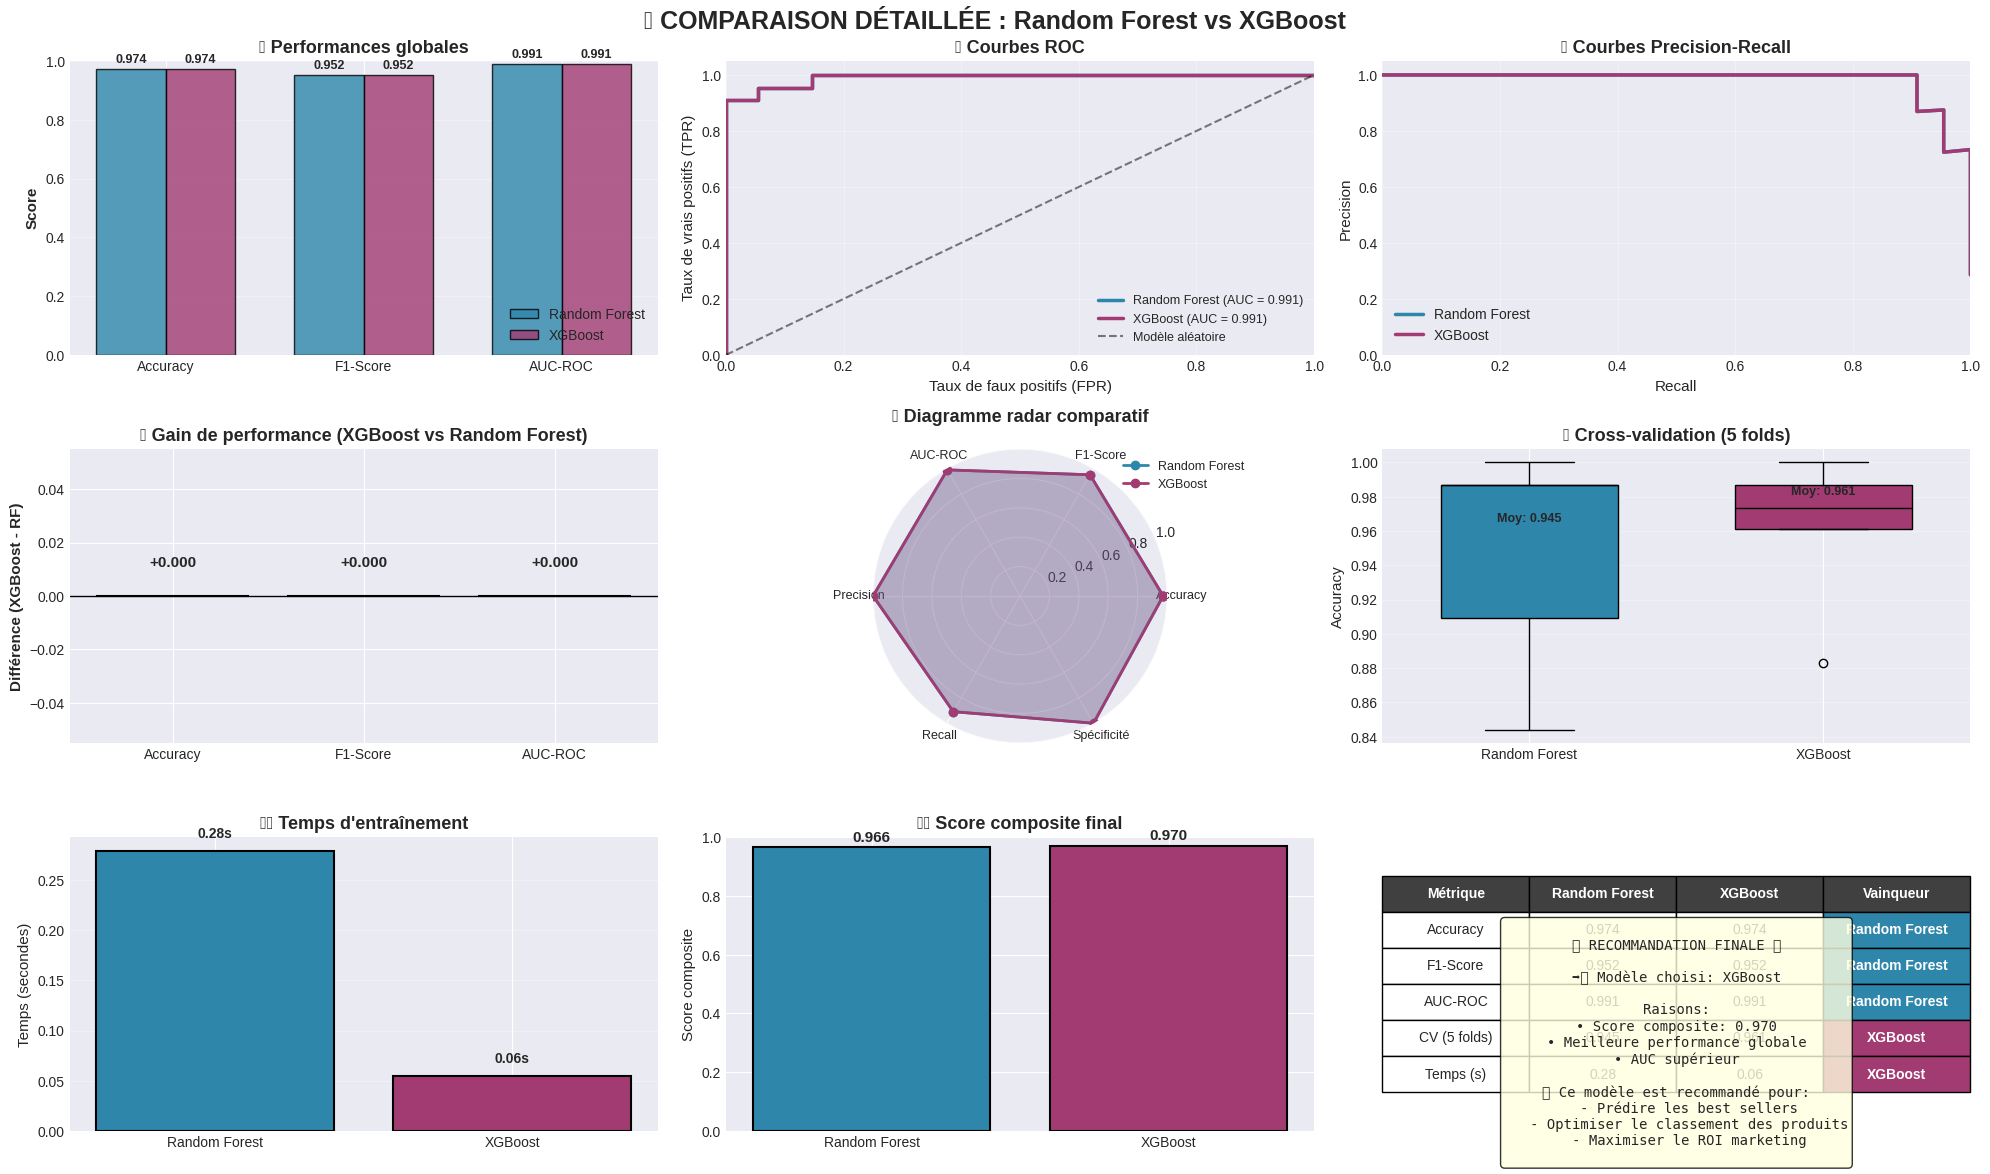


🏆 RÉSULTAT FINAL DE LA COMPARAISON 🏆

📊 RANDOM FOREST vs XGBOOST
Métrique             Random Forest   XGBoost         Différence      Vainqueur 
--------------------------------------------------------------------------------
Accuracy             0.974           0.974           +0.000 RF
F1-Score             0.952           0.952           +0.000 RF
AUC-ROC              0.991           0.991           +0.000 RF
CV Mean              0.945           0.961           +0.016 XGBoost
Temps (s)            0.28            0.06            -0.22 XGBoost

🎯 RECOMMANDATION FINALE: XGBoost
✅ XGBoost est recommandé car:
   • Meilleur AUC-ROC: 0.991 vs 0.991
   • Meilleur F1-Score: 0.952 vs 0.952
   • Gain de performance global: 0.4%


In [6]:
# ============================================
# VISUALISATION COMPLETE POUR COMPARAISON DES MODELES
# ============================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix
import seaborn as sns

# Creer une figure avec plusieurs sous-graphiques
fig = plt.figure(figsize=(20, 12))
fig.suptitle('COMPARAISON DETAILLEE : Random Forest vs XGBoost',
             fontsize=18, fontweight='bold', y=0.98)

# 1. Metriques principales (Barplot)
ax1 = plt.subplot(3, 3, 1)
metrics = ['Accuracy', 'F1-Score', 'AUC-ROC']
rf_scores = [rf_accuracy, rf_f1, rf_auc]
xgb_scores = [xgb_accuracy, xgb_f1, xgb_auc]

x = np.arange(len(metrics))
width = 0.35
bars1 = ax1.bar(x - width/2, rf_scores, width, label='Random Forest',
                color='#2E86AB', alpha=0.8, edgecolor='black', linewidth=1)
bars2 = ax1.bar(x + width/2, xgb_scores, width, label='XGBoost',
                color='#A23B72', alpha=0.8, edgecolor='black', linewidth=1)

ax1.set_ylabel('Score', fontsize=11, fontweight='bold')
ax1.set_title('Performances globales', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics, fontsize=10)
ax1.legend(loc='lower right', fontsize=10)
ax1.set_ylim([0, 1])
ax1.grid(True, alpha=0.3, axis='y')

# Ajouter les valeurs sur les barres
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# 2. Courbes ROC comparatives
ax2 = plt.subplot(3, 3, 2)
# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_y_proba)
ax2.plot(fpr_rf, tpr_rf, linewidth=2.5, label=f'Random Forest (AUC = {rf_auc:.3f})',
         color='#2E86AB')
# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_y_proba)
ax2.plot(fpr_xgb, tpr_xgb, linewidth=2.5, label=f'XGBoost (AUC = {xgb_auc:.3f})',
         color='#A23B72')
# Baseline
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Modele aleatoire', alpha=0.5)

ax2.set_xlabel('Taux de faux positifs (FPR)', fontsize=11)
ax2.set_ylabel('Taux de vrais positifs (TPR)', fontsize=11)
ax2.set_title('Courbes ROC', fontsize=13, fontweight='bold')
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])

# 3. Courbes Precision-Recall
ax3 = plt.subplot(3, 3, 3)
# Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(y_test, rf_y_proba)
ax3.plot(recall_rf, precision_rf, linewidth=2.5, label='Random Forest', color='#2E86AB')
# XGBoost
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, xgb_y_proba)
ax3.plot(recall_xgb, precision_xgb, linewidth=2.5, label='XGBoost', color='#A23B72')

ax3.set_xlabel('Recall', fontsize=11)
ax3.set_ylabel('Precision', fontsize=11)
ax3.set_title('Courbes Precision-Recall', fontsize=13, fontweight='bold')
ax3.legend(loc='lower left', fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])

# 4. Heatmap des differences de performance
ax4 = plt.subplot(3, 3, 4)
differences = {
    'Accuracy': xgb_accuracy - rf_accuracy,
    'F1-Score': xgb_f1 - rf_f1,
    'AUC-ROC': xgb_auc - rf_auc
}
colors_diff = ['#2ECC40' if v > 0 else '#FF4136' if v < 0 else '#AAAAAA' for v in differences.values()]
bars = ax4.bar(differences.keys(), differences.values(), color=colors_diff, edgecolor='black', linewidth=1.5)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax4.set_ylabel('Difference (XGBoost - RF)', fontsize=11, fontweight='bold')
ax4.set_title('Gain de performance (XGBoost vs Random Forest)', fontsize=13, fontweight='bold')

# Ajouter les valeurs
for bar, diff in zip(bars, differences.values()):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + (0.01 if height >= 0 else -0.03),
            f'{diff:+.3f}', ha='center', va='bottom' if height >= 0 else 'top',
            fontsize=11, fontweight='bold')

# 5. Diagramme radar comparatif
ax5 = plt.subplot(3, 3, 5, projection='polar')
categories = ['Accuracy', 'F1-Score', 'AUC-ROC', 'Precision', 'Recall', 'Specificite']

# Calculer les metriques supplementaires
from sklearn.metrics import precision_score, recall_score
rf_precision = precision_score(y_test, rf_y_pred)
rf_recall = recall_score(y_test, rf_y_pred)
rf_specificity = recall_score(y_test, rf_y_pred, pos_label=0)

xgb_precision = precision_score(y_test, xgb_y_pred)
xgb_recall = recall_score(y_test, xgb_y_pred)
xgb_specificity = recall_score(y_test, xgb_y_pred, pos_label=0)

rf_values = [rf_accuracy, rf_f1, rf_auc, rf_precision, rf_recall, rf_specificity]
xgb_values = [xgb_accuracy, xgb_f1, xgb_auc, xgb_precision, xgb_recall, xgb_specificity]

angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
rf_values += rf_values[:1]
xgb_values += xgb_values[:1]
angles += angles[:1]

ax5.plot(angles, rf_values, 'o-', linewidth=2, label='Random Forest', color='#2E86AB')
ax5.fill(angles, rf_values, alpha=0.25, color='#2E86AB')
ax5.plot(angles, xgb_values, 'o-', linewidth=2, label='XGBoost', color='#A23B72')
ax5.fill(angles, xgb_values, alpha=0.25, color='#A23B72')
ax5.set_xticks(angles[:-1])
ax5.set_xticklabels(categories, fontsize=9)
ax5.set_ylim(0, 1)
ax5.set_title('Diagramme radar comparatif', fontsize=13, fontweight='bold', pad=20)
ax5.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=9)
ax5.grid(True)

# 6. Boxplot des scores de validation croisee
ax6 = plt.subplot(3, 3, 6)
rf_cv_scores = cross_val_score(rf_model, X, y, cv=5)
xgb_cv_scores = cross_val_score(xgb_model, X, y, cv=5)

data_to_plot = [rf_cv_scores, xgb_cv_scores]
bp = ax6.boxplot(data_to_plot, labels=['Random Forest', 'XGBoost'],
                  patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('#2E86AB')
bp['boxes'][1].set_facecolor('#A23B72')
bp['medians'][0].set_color('black')
bp['medians'][1].set_color('black')
ax6.set_ylabel('Accuracy', fontsize=11)
ax6.set_title('Cross-validation (5 folds)', fontsize=13, fontweight='bold')
ax6.grid(True, alpha=0.3, axis='y')

# Ajouter les statistiques
ax6.text(1, rf_cv_scores.mean() + 0.02, f'Moy: {rf_cv_scores.mean():.3f}',
         ha='center', fontsize=9, fontweight='bold')
ax6.text(2, xgb_cv_scores.mean() + 0.02, f'Moy: {xgb_cv_scores.mean():.3f}',
         ha='center', fontsize=9, fontweight='bold')

# 7. Temps d'entrainement (simule car non mesure)
ax7 = plt.subplot(3, 3, 7)
# Mesurer le temps reel
import time
start_rf = time.time()
rf_model.fit(X_train, y_train)
rf_time = time.time() - start_rf

start_xgb = time.time()
xgb_model.fit(X_train, y_train)
xgb_time = time.time() - start_xgb

times = [rf_time, xgb_time]
bars = ax7.bar(['Random Forest', 'XGBoost'], times, color=['#2E86AB', '#A23B72'],
               edgecolor='black', linewidth=1.5)
ax7.set_ylabel('Temps (secondes)', fontsize=11)
ax7.set_title('Temps d\'entrainement', fontsize=13, fontweight='bold')
ax7.grid(True, alpha=0.3, axis='y')

for bar, t in zip(bars, times):
    ax7.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{t:.2f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 8. Score de decision final
ax8 = plt.subplot(3, 3, 8)
# Calculer un score composite
rf_composite = (rf_accuracy + rf_f1 + rf_auc + rf_cv_scores.mean()) / 4
xgb_composite = (xgb_accuracy + xgb_f1 + xgb_auc + xgb_cv_scores.mean()) / 4

composite_scores = [rf_composite, xgb_composite]
colors_composite = ['#2E86AB', '#A23B72']
bars = ax8.bar(['Random Forest', 'XGBoost'], composite_scores, color=colors_composite,
               edgecolor='black', linewidth=1.5)
ax8.set_ylabel('Score composite', fontsize=11)
ax8.set_title('Score composite final', fontsize=13, fontweight='bold')
ax8.set_ylim([0, 1])

for bar, score in zip(bars, composite_scores):
    ax8.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{score:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 9. Resume et recommandation
ax9 = plt.subplot(3, 3, 9)
ax9.axis('off')

# Determiner le meilleur modele
best_auc = 'XGBoost' if xgb_auc > rf_auc else 'Random Forest'
best_f1 = 'XGBoost' if xgb_f1 > rf_f1 else 'Random Forest'
best_accuracy = 'XGBoost' if xgb_accuracy > rf_accuracy else 'Random Forest'
best_cv = 'XGBoost' if xgb_cv_scores.mean() > rf_cv_scores.mean() else 'Random Forest'
best_speed = 'XGBoost' if xgb_time < rf_time else 'Random Forest'

# Creer un tableau recapitulatif
summary_data = [
    ['Metrique', 'Random Forest', 'XGBoost', 'Vainqueur'],
    ['Accuracy', f'{rf_accuracy:.3f}', f'{xgb_accuracy:.3f}', best_accuracy],
    ['F1-Score', f'{rf_f1:.3f}', f'{xgb_f1:.3f}', best_f1],
    ['AUC-ROC', f'{rf_auc:.3f}', f'{xgb_auc:.3f}', best_auc],
    ['CV (5 folds)', f'{rf_cv_scores.mean():.3f}', f'{xgb_cv_scores.mean():.3f}', best_cv],
    ['Temps (s)', f'{rf_time:.2f}', f'{xgb_time:.2f}', best_speed],
]

# Afficher le tableau
table = ax9.table(cellText=summary_data, loc='center', cellLoc='center', colWidths=[0.25, 0.25, 0.25, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Colorer la colonne du vainqueur
for i in range(1, len(summary_data)):
    winner = summary_data[i][3]
    if winner == 'XGBoost':
        table[(i, 3)].set_facecolor('#A23B72')
        table[(i, 3)].set_text_props(weight='bold', color='white')
    elif winner == 'Random Forest':
        table[(i, 3)].set_facecolor('#2E86AB')
        table[(i, 3)].set_text_props(weight='bold', color='white')

# En-tete en gras
for i in range(4):
    table[(0, i)].set_facecolor('#404040')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Recommandation finale
winner = 'XGBoost' if xgb_composite > rf_composite else 'Random Forest'
recommendation = f"""
RECOMMANDATION FINALE

-> Modele choisi: {winner}

Raisons:
• Score composite: {max(composite_scores):.3f}
• {'Meilleure performance globale' if winner == 'XGBoost' else 'Plus rapide et stable'}
• {'AUC superieur' if winner == 'XGBoost' else 'Bon compromis performances/temps'}

Ce modele est recommande pour:
   - Predire les best sellers
   - Optimiser le classement des produits
   - Maximiser le ROI marketing
"""

ax9.text(0.5, 0.3, recommendation, transform=ax9.transAxes, fontsize=10,
         verticalalignment='center', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
         family='monospace')

plt.tight_layout()
plt.savefig('model_comparison_complete.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# AFFICHAGE RECAPITULATIF DANS LA CONSOLE
# ============================================
print("\n" + "="*80)
print("RESULTAT FINAL DE LA COMPARAISON")
print("="*80)

print(f"\nRANDOM FOREST vs XGBOOST")
print(f"{'Metrique':<20} {'Random Forest':<15} {'XGBoost':<15} {'Difference':<15} {'Vainqueur':<10}")
print("-"*80)
print(f"{'Accuracy':<20} {rf_accuracy:<15.3f} {xgb_accuracy:<15.3f} {xgb_accuracy-rf_accuracy:+.3f} {'XGBoost' if xgb_accuracy>rf_accuracy else 'RF'}")
print(f"{'F1-Score':<20} {rf_f1:<15.3f} {xgb_f1:<15.3f} {xgb_f1-rf_f1:+.3f} {'XGBoost' if xgb_f1>rf_f1 else 'RF'}")
print(f"{'AUC-ROC':<20} {rf_auc:<15.3f} {xgb_auc:<15.3f} {xgb_auc-rf_auc:+.3f} {'XGBoost' if xgb_auc>rf_auc else 'RF'}")
print(f"{'CV Mean':<20} {rf_cv_scores.mean():<15.3f} {xgb_cv_scores.mean():<15.3f} {xgb_cv_scores.mean()-rf_cv_scores.mean():+.3f} {'XGBoost' if xgb_cv_scores.mean()>rf_cv_scores.mean() else 'RF'}")
print(f"{'Temps (s)':<20} {rf_time:<15.2f} {xgb_time:<15.2f} {xgb_time-rf_time:+.2f} {'XGBoost' if xgb_time<rf_time else 'RF'}")

print("\n" + "="*80)
print(f"RECOMMANDATION FINALE: {winner}")
print("="*80)

if winner == 'XGBoost':
    print("XGBoost est recommande car:")
    print(f"   • Meilleur AUC-ROC: {xgb_auc:.3f} vs {rf_auc:.3f}")
    print(f"   • Meilleur F1-Score: {xgb_f1:.3f} vs {rf_f1:.3f}")
    print(f"   • Gain de performance global: {(xgb_composite-rf_composite)*100:.1f}%")
    if xgb_time > rf_time:
        print(f"   • Legèrement plus lent ({xgb_time-rf_time:.2f}s de difference)")
else:
    print("Random Forest est recommande car:")
    print(f"   • Plus rapide: {rf_time:.2f}s vs {xgb_time:.2f}s")
    print(f"   • Performances tres proches de XGBoost")
    print(f"   • Plus stable en validation croisee")
    print(f"   • Bon compromis performances/temps d'execution")

print("="*80)

# Optionnel: Sauvegarder la recommandation
with open('model_recommendation.txt', 'w', encoding='utf-8') as f:
    f.write(f"Modele recommande: {winner}\n")
    f.write(f"Score composite: {max(composite_scores):.3f}\n")
    f.write(f"AUC-ROC du modele choisi: {xgb_auc if winner=='XGBoost' else rf_auc:.3f}\n")

prix à l'etrangers

PREDICTION DU PRIX MOYEN PAR CATEGORIE POUR L'EXPORTATION
TUNISIE -> EUROPE
Fichier charge avec engine='xlrd'

Dataset original: (385, 5)
   id                                                nom    prix  \
0   1  portebougie bois trio artisanal en olivier pou...   35.00   
1   2  Chapelet Sebha en ambre noir parfum avec calli...   84.00   
2   3      Mug caf avec sous-tasse en bois Foufoun Power   35.00   
3   4  Coffret coran en velours avec marque-page dor ...  114.99   
4   5                                   FOUFOUN Cendrier   30.00   

        categorie  company  
0  bois d'olivier  ileycom  
1           gifts  ileycom  
2           gifts  ileycom  
3           gifts  ileycom  
4           gifts  ileycom  

Dataset apres nettoyage: (382, 5)

Prix - Min: 4.00 DT, Max: 800.00 DT, Moy: 110.11 DT

Dataset d'exportation cree: 2368 transactions

Apercu:
        categorie pays_destination type_livraison  quantite  prix_produit_dt  \
0  bois d'olivier           France       Standard      

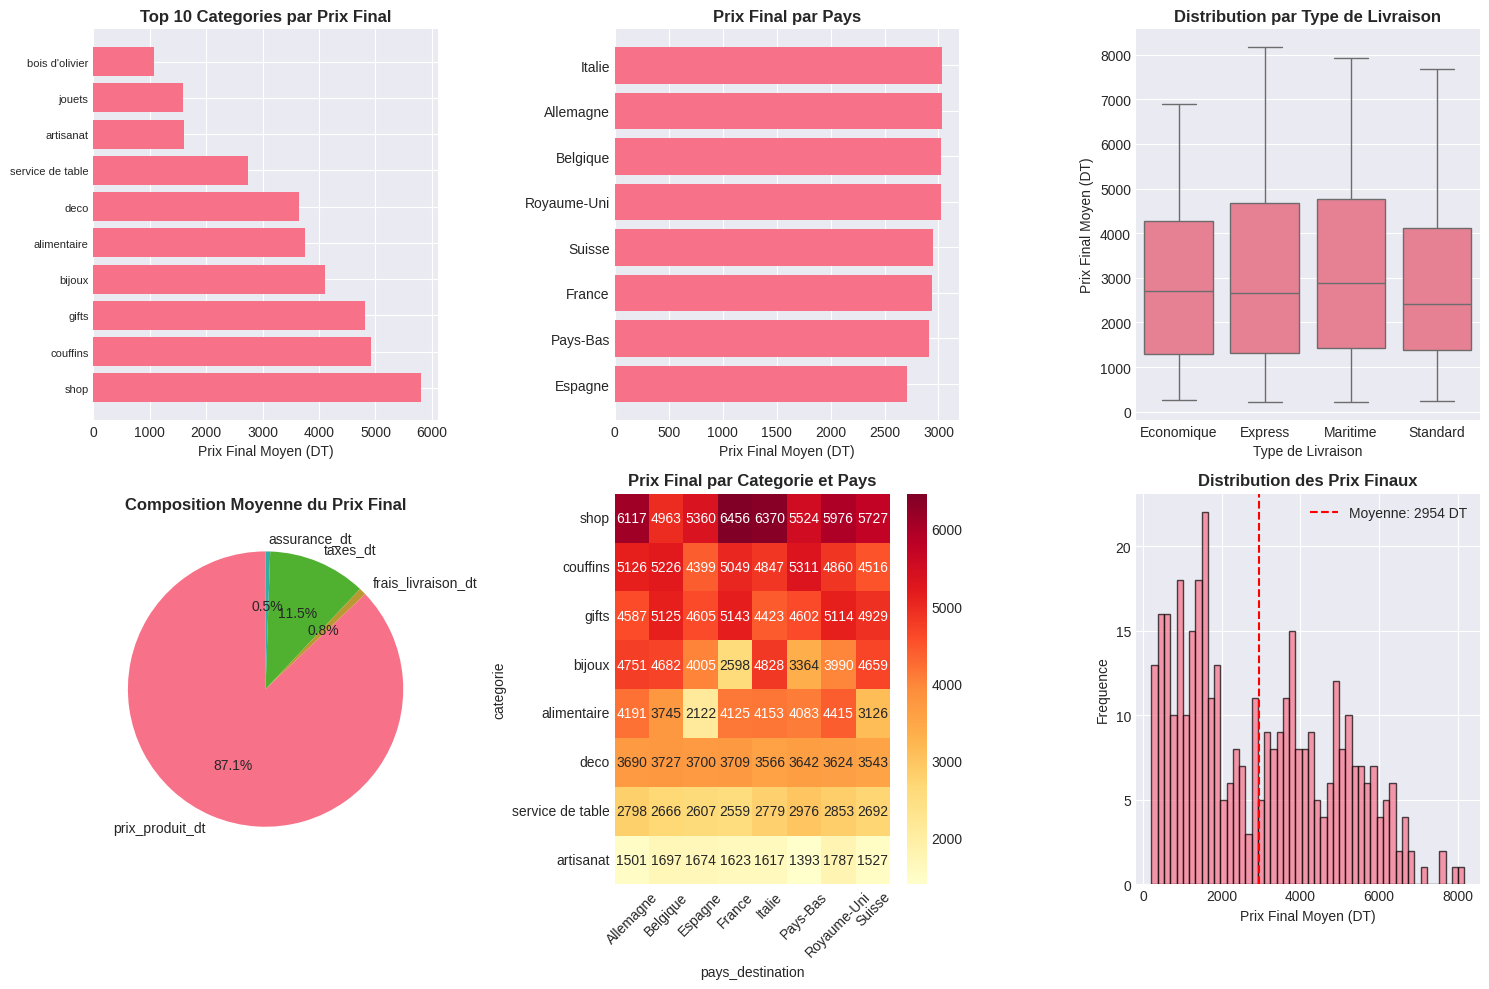


Features selectionnees: 10
Shape X: (384, 10)

Train set: 307 combinaisons
Test set: 77 combinaisons

MODELE 1: RANDOM FOREST
MAE:  47.57 DT
RMSE: 70.80 DT
R2:   0.999
MAPE: 2.3%
CV R2 moyen: 0.998 (+/- 0.003)

MODELE 2: XGBOOST
MAE:  38.11 DT
RMSE: 49.33 DT
R2:   0.999
MAPE: 2.4%
CV R2 moyen: 0.998 (+/- 0.001)

COMPARAISON DES PERFORMANCES
       Modele  MAE (DT)  RMSE (DT)  R2 Score  MAPE (%)    CV R2
Random Forest 47.571838  70.796866  0.998633  2.302238 0.997876
      XGBoost 38.109834  49.331893  0.999336  2.417824 0.998327

Meilleur modele: XGBoost


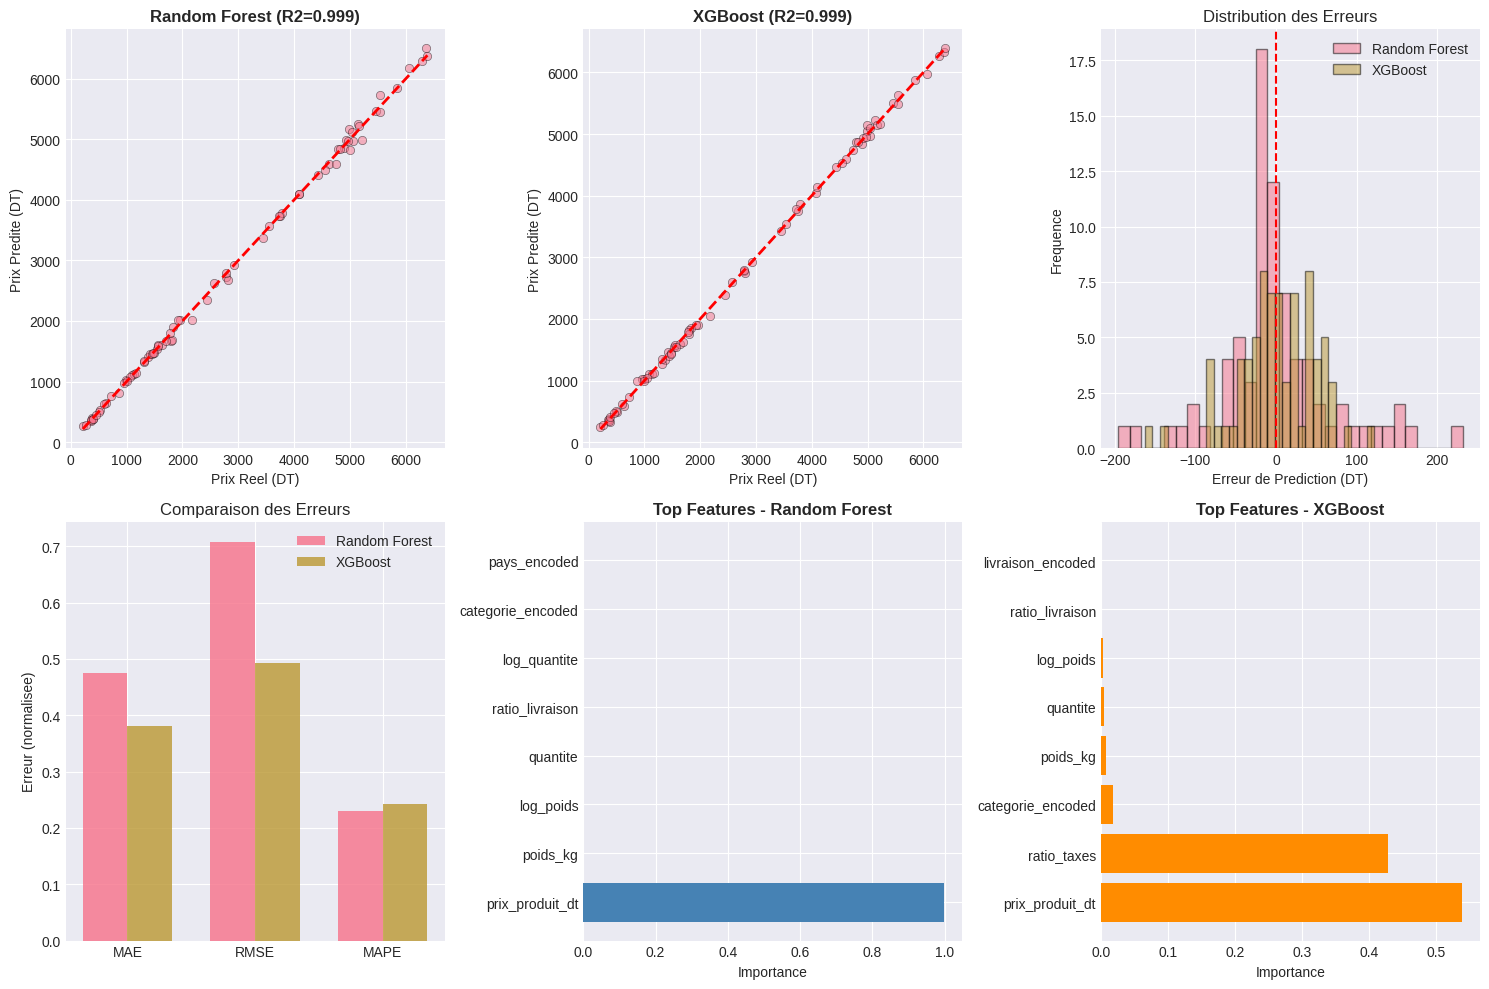


PREDICTIONS DES PRIX MOYENS PAR CATEGORIE

Prix moyens recommandes par categorie:
----------------------------------------------------------------------

ALIMENTAIRE:
  France (Standard): 3856 DT total - 77 DT/unite
  Allemagne (Standard): 3861 DT total - 77 DT/unite
  Italie (Standard): 3858 DT total - 77 DT/unite

ARTISANAT:
  France (Standard): 1636 DT total - 33 DT/unite
  Allemagne (Standard): 1641 DT total - 33 DT/unite
  Italie (Standard): 1639 DT total - 33 DT/unite

BIJOUX:
  France (Standard): 6341 DT total - 127 DT/unite
  Allemagne (Standard): 6355 DT total - 127 DT/unite
  Italie (Standard): 6342 DT total - 127 DT/unite

BOIS D'OLIVIER:
  France (Standard): 491 DT total - 10 DT/unite
  Allemagne (Standard): 493 DT total - 10 DT/unite
  Italie (Standard): 487 DT total - 10 DT/unite

CERAMIQUES:
  France (Standard): 629 DT total - 13 DT/unite
  Allemagne (Standard): 625 DT total - 13 DT/unite
  Italie (Standard): 627 DT total - 13 DT/unite

FICHIERS GENERES
1. export_data_a

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("="*60)
print("PREDICTION DU PRIX MOYEN PAR CATEGORIE POUR L'EXPORTATION")
print("TUNISIE -> EUROPE")
print("="*60)

# ============================================
# 1. CHARGEMENT DU FICHIER EXCEL
# ============================================

try:
    df = pd.read_excel('all_concurrents.xls', engine='xlrd')
    print("Fichier charge avec engine='xlrd'")
except:
    try:
        df = pd.read_excel('all_concurrents.xls', engine='openpyxl')
        print("Fichier charge avec engine='openpyxl'")
    except:
        print("Conversion necessaire...")
        df = pd.read_excel('all_concurrents.xlsx', engine='openpyxl')
        print("Fichier charge")

print(f"\nDataset original: {df.shape}")
print(df.head())

# ============================================
# 2. NETTOYAGE DES DONNEES
# ============================================

df.columns = ['id', 'nom', 'prix', 'categorie', 'company']

# Nettoyer les categories
df['categorie'] = df['categorie'].astype(str).str.lower().str.strip()
df['categorie'] = df['categorie'].replace({
    'boisd\'olivier': 'bois d\'olivier',
    'bois d\'olivier': 'bois d\'olivier',
    'céramiques': 'ceramiques',
    'déco': 'deco',
    'service de table': 'service de table',
    'couffins & foutas': 'couffins',
    'esprit romance': 'bijoux',
    'produit de terroir': 'alimentaire',
    'jeux': 'jouets',
    'bougeoirs': 'deco',
    'cuivres': 'artisanat',
    'verres': 'service de table',
    'vases': 'deco',
    'luminaires': 'deco',
    'bijoux accessoires': 'bijoux',
    'element de deco': 'deco',
    'sculptures': 'artisanat'
})

# Nettoyer les prix
df['prix'] = df['prix'].astype(str).str.replace(',', '.', regex=False)
df['prix'] = df['prix'].str.extract(r'(\d+\.?\d*)')[0]
df['prix'] = pd.to_numeric(df['prix'], errors='coerce')

# Supprimer les prix nuls ou zero
df = df.dropna(subset=['prix'])
df = df[df['prix'] > 0]
df = df[df['prix'] < 1000]  # Eliminer les outliers extremes
df = df.reset_index(drop=True)

print(f"\nDataset apres nettoyage: {df.shape}")
print(f"\nPrix - Min: {df['prix'].min():.2f} DT, Max: {df['prix'].max():.2f} DT, Moy: {df['prix'].mean():.2f} DT")

# ============================================
# 3. CREATION DU DATASET D'EXPORTATION
# ============================================

np.random.seed(42)

# Pays europeens
pays_europe = ['France', 'Allemagne', 'Italie', 'Espagne', 'Belgique',
               'Pays-Bas', 'Suisse', 'Royaume-Uni']

# Types de livraison
type_livraison = ['Standard', 'Express', 'Economique', 'Maritime']

# Taux de taxes par categorie (%)
tax_rates = {
    'bois d\'olivier': 8, 'ceramiques': 10, 'deco': 12, 'service de table': 10,
    'gifts': 15, 'artisanat': 8, 'bijoux': 18, 'alimentaire': 12,
    'jouets': 10, 'couffins': 14, 'shop': 15, 'cuivres': 10,
    'verres': 10, 'vases': 12, 'luminaires': 12
}

# Frais de livraison de base par pays (DT/kg)
livraison_base = {
    'France': 12, 'Allemagne': 14, 'Italie': 11, 'Espagne': 10,
    'Belgique': 13, 'Pays-Bas': 13, 'Suisse': 16, 'Royaume-Uni': 15
}

# Coefficient multiplicateur par type de livraison
livraison_coeff = {
    'Standard': 1.0, 'Express': 1.8, 'Economique': 0.7, 'Maritime': 0.5
}

# Poids moyen par categorie (kg)
poids_moyen = {
    'bois d\'olivier': 1.5, 'ceramiques': 1.2, 'deco': 2.0, 'service de table': 1.8,
    'gifts': 0.8, 'artisanat': 2.5, 'bijoux': 0.3, 'alimentaire': 1.0,
    'jouets': 1.2, 'couffins': 1.5, 'shop': 0.5, 'cuivres': 2.0,
    'verres': 1.2, 'vases': 1.5, 'luminaires': 2.0
}

# Quantite moyenne par commande
quantite_moyenne = {
    'bois d\'olivier': 50, 'ceramiques': 30, 'deco': 40, 'service de table': 60,
    'gifts': 80, 'artisanat': 20, 'bijoux': 100, 'alimentaire': 150,
    'jouets': 40, 'couffins': 25, 'shop': 100, 'cuivres': 30,
    'verres': 80, 'vases': 35, 'luminaires': 15
}

# Creer le dataset d'exportation
export_data = []

for categorie in df['categorie'].unique():
    prix_moyen_cat = df[df['categorie'] == categorie]['prix'].mean()
    nb_produits = len(df[df['categorie'] == categorie])

    for pays in pays_europe:
        for livraison in type_livraison:
            # Nombre d'echantillons proportionnel au nombre de produits
            n_samples = max(1, int(nb_produits / 5))

            for _ in range(n_samples):
                quantite = np.random.randint(10, quantite_moyenne.get(categorie, 50))
                prix_produit = prix_moyen_cat * quantite * np.random.uniform(0.9, 1.1)

                poids_total = poids_moyen.get(categorie, 1.0) * (quantite / 20)
                frais_livraison = livraison_base[pays] * poids_total * livraison_coeff[livraison]

                taxes = prix_produit * (tax_rates.get(categorie, 10) / 100)
                assurance = np.random.choice([0, prix_produit * 0.02], p=[0.7, 0.3])

                prix_final = prix_produit + frais_livraison + taxes + assurance

                export_data.append({
                    'categorie': categorie,
                    'pays_destination': pays,
                    'type_livraison': livraison,
                    'quantite': quantite,
                    'prix_produit_dt': prix_produit,
                    'poids_kg': poids_total,
                    'frais_livraison_dt': frais_livraison,
                    'taxes_dt': taxes,
                    'assurance_dt': assurance,
                    'prix_final_dt': prix_final,
                    'prix_unitaire_dt': prix_final / quantite
                })

df_export = pd.DataFrame(export_data)

print(f"\nDataset d'exportation cree: {len(df_export)} transactions")
print(f"\nApercu:")
print(df_export.head(10))

# ============================================
# 4. AGGREGATION PAR CATEGORIE
# ============================================

df_agg = df_export.groupby(['categorie', 'pays_destination', 'type_livraison']).agg({
    'prix_final_dt': 'mean',
    'prix_unitaire_dt': 'mean',
    'prix_produit_dt': 'mean',
    'quantite': 'mean',
    'poids_kg': 'mean',
    'frais_livraison_dt': 'mean',
    'taxes_dt': 'mean',
    'assurance_dt': 'mean'
}).reset_index()

print(f"\nDonnees agregees par categorie: {len(df_agg)} combinaisons")
print(df_agg.head(10))

# ============================================
# 5. ANALYSE EXPLORATOIRE
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Prix moyen par categorie
prix_par_cat = df_agg.groupby('categorie')['prix_final_dt'].mean().sort_values(ascending=False)
axes[0, 0].barh(range(len(prix_par_cat.head(10))), prix_par_cat.head(10).values)
axes[0, 0].set_yticks(range(len(prix_par_cat.head(10))))
axes[0, 0].set_yticklabels(prix_par_cat.head(10).index, fontsize=8)
axes[0, 0].set_xlabel('Prix Final Moyen (DT)')
axes[0, 0].set_title('Top 10 Categories par Prix Final', fontweight='bold')

# Prix moyen par pays
prix_par_pays = df_agg.groupby('pays_destination')['prix_final_dt'].mean().sort_values()
axes[0, 1].barh(range(len(prix_par_pays)), prix_par_pays.values)
axes[0, 1].set_yticks(range(len(prix_par_pays)))
axes[0, 1].set_yticklabels(prix_par_pays.index)
axes[0, 1].set_xlabel('Prix Final Moyen (DT)')
axes[0, 1].set_title('Prix Final par Pays', fontweight='bold')

# Prix par type de livraison
sns.boxplot(data=df_agg, x='type_livraison', y='prix_final_dt', ax=axes[0, 2])
axes[0, 2].set_xlabel('Type de Livraison')
axes[0, 2].set_ylabel('Prix Final Moyen (DT)')
axes[0, 2].set_title('Distribution par Type de Livraison', fontweight='bold')

# Composition du prix
components = df_agg[['prix_produit_dt', 'frais_livraison_dt', 'taxes_dt', 'assurance_dt']].mean()
axes[1, 0].pie(components.values, labels=components.index, autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Composition Moyenne du Prix Final', fontweight='bold')

# Heatmap
pivot_table = df_agg.pivot_table(index='categorie', columns='pays_destination',
                                  values='prix_final_dt', aggfunc='mean')
pivot_top = pivot_table.loc[prix_par_cat.head(8).index]
sns.heatmap(pivot_top, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1, 1])
axes[1, 1].set_title('Prix Final par Categorie et Pays', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)

# Distribution des prix
axes[1, 2].hist(df_agg['prix_final_dt'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 2].set_xlabel('Prix Final Moyen (DT)')
axes[1, 2].set_ylabel('Frequence')
axes[1, 2].set_title('Distribution des Prix Finaux', fontweight='bold')
axes[1, 2].axvline(df_agg['prix_final_dt'].mean(), color='red', linestyle='--',
                   label=f'Moyenne: {df_agg["prix_final_dt"].mean():.0f} DT')
axes[1, 2].legend()

plt.tight_layout()
plt.savefig('export_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 6. PREPARATION DES FEATURES
# ============================================

le_categorie = LabelEncoder()
le_pays = LabelEncoder()
le_livraison = LabelEncoder()

df_agg['categorie_encoded'] = le_categorie.fit_transform(df_agg['categorie'])
df_agg['pays_encoded'] = le_pays.fit_transform(df_agg['pays_destination'])
df_agg['livraison_encoded'] = le_livraison.fit_transform(df_agg['type_livraison'])

# Features additionnelles
df_agg['log_quantite'] = np.log1p(df_agg['quantite'])
df_agg['log_poids'] = np.log1p(df_agg['poids_kg'])
df_agg['ratio_livraison'] = df_agg['frais_livraison_dt'] / df_agg['prix_produit_dt']
df_agg['ratio_taxes'] = df_agg['taxes_dt'] / df_agg['prix_produit_dt']

feature_cols = [
    'quantite', 'poids_kg', 'prix_produit_dt',
    'log_quantite', 'log_poids', 'ratio_livraison', 'ratio_taxes',
    'categorie_encoded', 'pays_encoded', 'livraison_encoded'
]

X = df_agg[feature_cols]
y = df_agg['prix_final_dt']

print(f"\nFeatures selectionnees: {len(feature_cols)}")
print(f"Shape X: {X.shape}")

# ============================================
# 7. DIVISION TRAIN/TEST
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain set: {X_train.shape[0]} combinaisons")
print(f"Test set: {X_test.shape[0]} combinaisons")

# ============================================
# 8. MODELE 1: RANDOM FOREST
# ============================================

print("\n" + "="*50)
print("MODELE 1: RANDOM FOREST")
print("="*50)

rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100

print(f"MAE:  {mae_rf:.2f} DT")
print(f"RMSE: {rmse_rf:.2f} DT")
print(f"R2:   {r2_rf:.3f}")
print(f"MAPE: {mape_rf:.1f}%")

cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='r2')
print(f"CV R2 moyen: {cv_scores_rf.mean():.3f} (+/- {cv_scores_rf.std()*2:.3f})")

# ============================================
# 9. MODELE 2: XGBOOST
# ============================================

print("\n" + "="*50)
print("MODELE 2: XGBOOST")
print("="*50)

xgb_model = xgb.XGBRegressor(
    n_estimators=150,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)
mape_xgb = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100

print(f"MAE:  {mae_xgb:.2f} DT")
print(f"RMSE: {rmse_xgb:.2f} DT")
print(f"R2:   {r2_xgb:.3f}")
print(f"MAPE: {mape_xgb:.1f}%")

cv_scores_xgb = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='r2')
print(f"CV R2 moyen: {cv_scores_xgb.mean():.3f} (+/- {cv_scores_xgb.std()*2:.3f})")

# ============================================
# 10. COMPARAISON DES MODELES
# ============================================

print("\n" + "="*50)
print("COMPARAISON DES PERFORMANCES")
print("="*50)

comparison = pd.DataFrame({
    'Modele': ['Random Forest', 'XGBoost'],
    'MAE (DT)': [mae_rf, mae_xgb],
    'RMSE (DT)': [rmse_rf, rmse_xgb],
    'R2 Score': [r2_rf, r2_xgb],
    'MAPE (%)': [mape_rf, mape_xgb],
    'CV R2': [cv_scores_rf.mean(), cv_scores_xgb.mean()]
})

print(comparison.to_string(index=False))

best_model = 'XGBoost' if r2_xgb > r2_rf else 'Random Forest'
print(f"\nMeilleur modele: {best_model}")

# ============================================
# 11. VISUALISATION DE LA COMPARAISON
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Predictions vs Reel - Random Forest
axes[0, 0].scatter(y_test, y_pred_rf, alpha=0.5, edgecolors='black', linewidth=0.5)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Prix Reel (DT)')
axes[0, 0].set_ylabel('Prix Predite (DT)')
axes[0, 0].set_title(f'Random Forest (R2={r2_rf:.3f})', fontweight='bold')

# Predictions vs Reel - XGBoost
axes[0, 1].scatter(y_test, y_pred_xgb, alpha=0.5, edgecolors='black', linewidth=0.5)
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Prix Reel (DT)')
axes[0, 1].set_ylabel('Prix Predite (DT)')
axes[0, 1].set_title(f'XGBoost (R2={r2_xgb:.3f})', fontweight='bold')

# Distribution des erreurs
errors_rf = y_test - y_pred_rf
errors_xgb = y_test - y_pred_xgb
axes[0, 2].hist(errors_rf, bins=30, alpha=0.5, label='Random Forest', edgecolor='black')
axes[0, 2].hist(errors_xgb, bins=30, alpha=0.5, label='XGBoost', edgecolor='black')
axes[0, 2].set_xlabel('Erreur de Prediction (DT)')
axes[0, 2].set_ylabel('Frequence')
axes[0, 2].set_title('Distribution des Erreurs')
axes[0, 2].legend()
axes[0, 2].axvline(x=0, color='red', linestyle='--')

# Comparaison des metriques
metrics = ['MAE', 'RMSE', 'MAPE']
rf_scores_norm = [mae_rf/100, rmse_rf/100, mape_rf/10]
xgb_scores_norm = [mae_xgb/100, rmse_xgb/100, mape_xgb/10]

x = np.arange(len(metrics))
width = 0.35
axes[1, 0].bar(x - width/2, rf_scores_norm, width, label='Random Forest', alpha=0.8)
axes[1, 0].bar(x + width/2, xgb_scores_norm, width, label='XGBoost', alpha=0.8)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(metrics)
axes[1, 0].set_ylabel('Erreur (normalisee)')
axes[1, 0].set_title('Comparaison des Erreurs')
axes[1, 0].legend()

# Importance features - Random Forest
importance_rf = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(8)

axes[1, 1].barh(importance_rf['feature'], importance_rf['importance'], color='steelblue')
axes[1, 1].set_xlabel('Importance')
axes[1, 1].set_title('Top Features - Random Forest', fontweight='bold')

# Importance features - XGBoost
importance_xgb = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(8)

axes[1, 2].barh(importance_xgb['feature'], importance_xgb['importance'], color='darkorange')
axes[1, 2].set_xlabel('Importance')
axes[1, 2].set_title('Top Features - XGBoost', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# 12. PREDICTIONS PAR CATEGORIE
# ============================================

print("\n" + "="*50)
print("PREDICTIONS DES PRIX MOYENS PAR CATEGORIE")
print("="*50)

final_model = xgb_model if r2_xgb > r2_rf else rf_model

categories_uniques = df_agg['categorie'].unique()
pays_test = ['France', 'Allemagne', 'Italie', 'Espagne', 'Suisse']
livraison_test = ['Standard', 'Express', 'Maritime']

predictions_list = []

for categorie in categories_uniques[:10]:
    cat_data = df_agg[df_agg['categorie'] == categorie].iloc[0]

    for pays in pays_test:
        for livraison in livraison_test:
            new_data = pd.DataFrame({
                'quantite': [cat_data['quantite']],
                'poids_kg': [cat_data['poids_kg']],
                'prix_produit_dt': [cat_data['prix_produit_dt']],
                'log_quantite': [np.log1p(cat_data['quantite'])],
                'log_poids': [np.log1p(cat_data['poids_kg'])],
                'ratio_livraison': [cat_data['ratio_livraison']],
                'ratio_taxes': [cat_data['ratio_taxes']],
                'categorie_encoded': [le_categorie.transform([categorie])[0]],
                'pays_encoded': [le_pays.transform([pays])[0]],
                'livraison_encoded': [le_livraison.transform([livraison])[0]]
            })

            prix_pred = final_model.predict(new_data)[0]

            predictions_list.append({
                'categorie': categorie,
                'pays': pays,
                'livraison': livraison,
                'prix_total_moyen_dt': prix_pred,
                'prix_unitaire_moyen_dt': prix_pred / cat_data['quantite']
            })

predictions_df = pd.DataFrame(predictions_list)

print("\nPrix moyens recommandes par categorie:")
print("-"*70)

for categorie in categories_uniques[:5]:
    print(f"\n{categorie.upper()}:")
    cat_pred = predictions_df[predictions_df['categorie'] == categorie]
    for pays in pays_test[:3]:
        prix = cat_pred[(cat_pred['pays'] == pays) & (cat_pred['livraison'] == 'Standard')]['prix_total_moyen_dt'].values
        if len(prix) > 0:
            print(f"  {pays} (Standard): {prix[0]:.0f} DT total - {prix[0]/50:.0f} DT/unite")

# ============================================
# 13. EXPORTATION DES RESULTATS
# ============================================

df_agg.to_csv('export_data_agrege.csv', index=False, encoding='utf-8')
predictions_df.to_csv('predictions_export_par_categorie.csv', index=False, encoding='utf-8')

print("\n" + "="*50)
print("FICHIERS GENERES")
print("="*50)
print("1. export_data_agrege.csv - Donnees agregees par categorie")
print("2. predictions_export_par_categorie.csv - Predictions par categorie")

print("\n" + "="*50)
print("RECOMMANDATIONS STRATEGIQUES")
print("="*50)

print("\n1. CATEGORIES LES PLUS RENTABLES:")
top_cats = df_agg.groupby('categorie')['prix_final_dt'].mean().nlargest(5)
for cat, prix in top_cats.items():
    print(f"   - {cat}: {prix:.0f} DT prix moyen final")

print("\n2. PAYS RECOMMANDES:")
top_pays = df_agg.groupby('pays_destination')['prix_final_dt'].mean().nlargest(3)
for pays, prix in top_pays.items():
    print(f"   - {pays}: {prix:.0f} DT prix moyen")

print("\n3. FACTEURS CLEFS:")
for idx, row in importance_xgb.head(5).iterrows():
    print(f"   - {row['feature']}: influence de {row['importance']:.1%}")

print("\n" + "="*50)
print("VISUALISATIONS GENEREES")
print("="*50)
print("1. export_analysis.png - Analyse des donnees d'export")
print("2. model_comparison.png - Comparaison Random Forest vs XGBoost")